In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

radius_values = np.concatenate([
    np.full(17, 0.0113226119),
    np.full(17, 0.0001132261),
    np.full(17, 0.0000011323)
])# m, radii needed to achieve Oh values

velocity_values = np.array([
    1.029478574, 1.455902561, 1.783109195, 2.058957148, 2.301984072, 3.255497096,
    4.603968145, 5.638686374, 6.510994191, 7.279512806, 10.29478574,
    14.55902561, 17.83109195, 20.58957148, 23.01984072, 32.55497096,
    46.03968145, 
    10.29478574, 14.55902561, 17.83109195, 20.58957148, 23.01984072,
    32.55497096, 46.03968145, 56.38686374, 65.10994191, 72.79512806,
    102.9478574, 145.5902561, 178.3109195, 205.8957148, 230.1984072,
    325.5497096, 460.3968145, 
    102.9478574, 145.5902561, 178.3109195, 205.8957148,
    230.1984072, 325.5497096, 460.3968145, 563.8686374, 651.0994191,
    727.9512806, 1029.478574, 1455.902561, 1783.109195, 2058.957148,
    2301.984072, 3255.497096, 4603.968145
])# m/s, velocity values

O'ROUKE MODEL

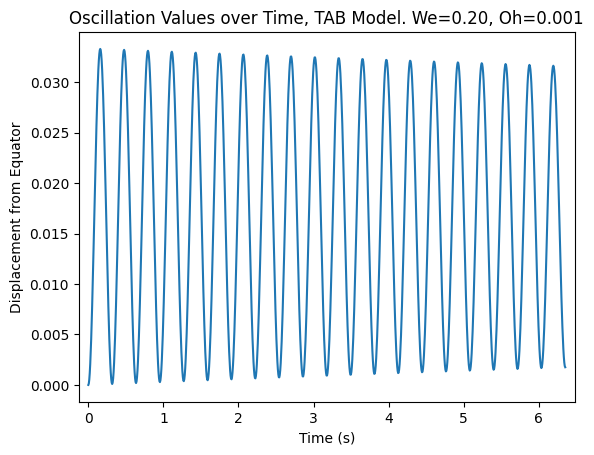

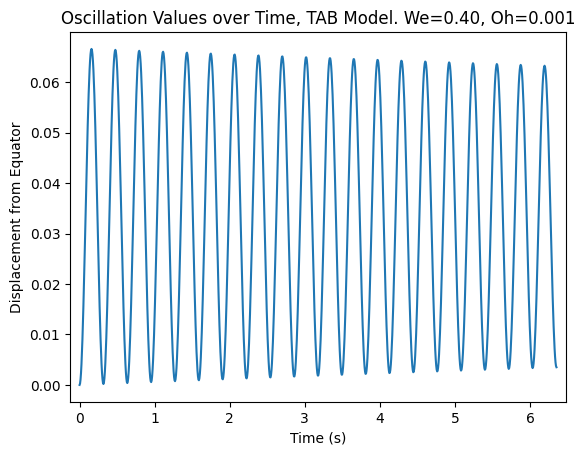

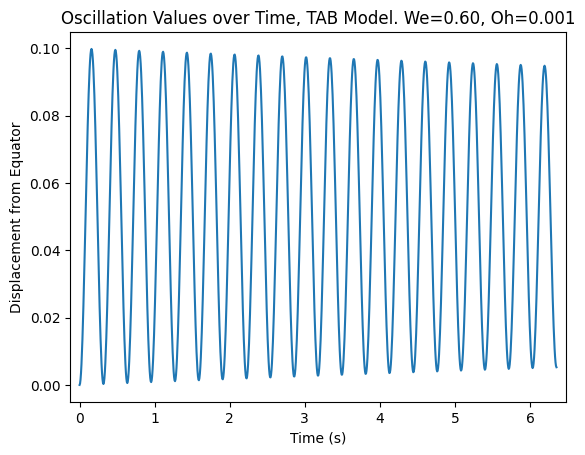

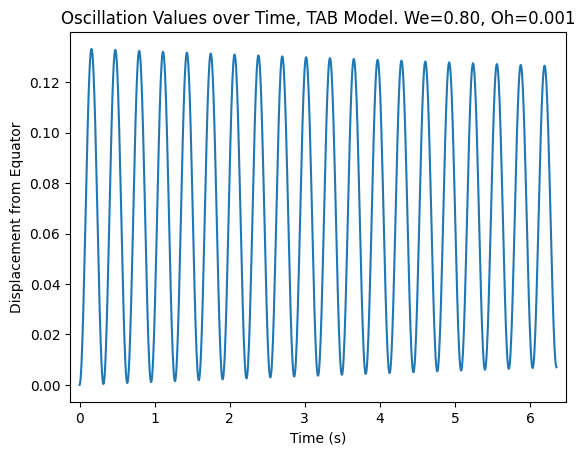

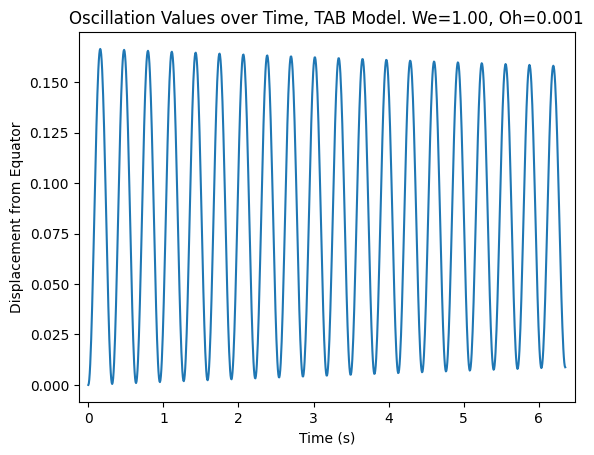

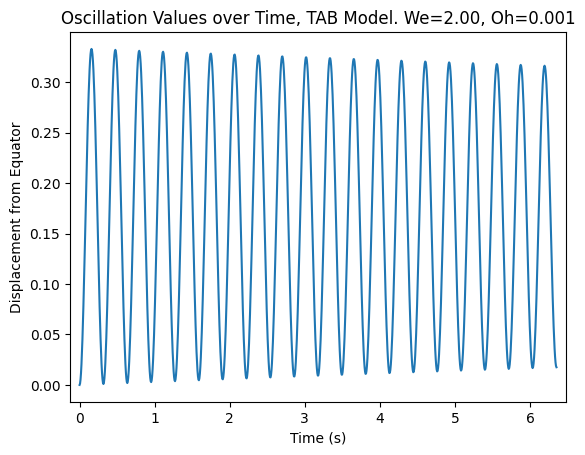

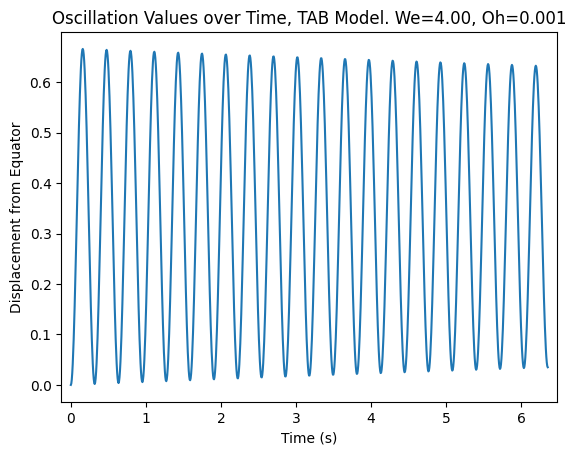

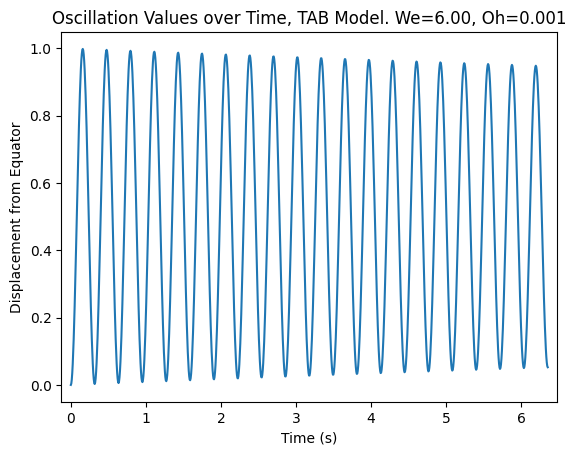

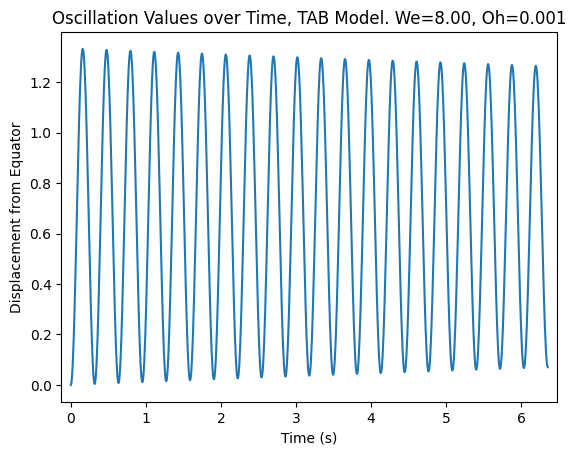

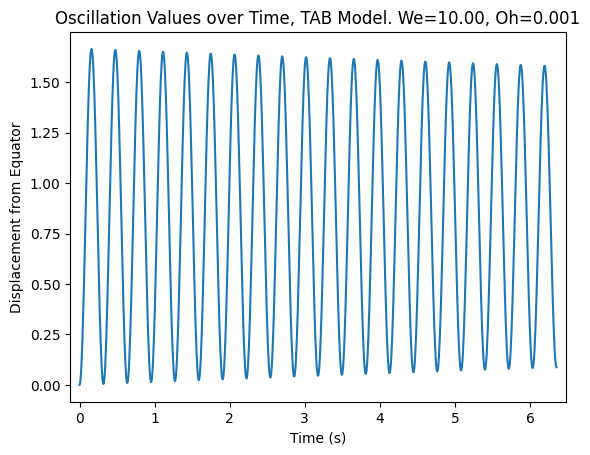

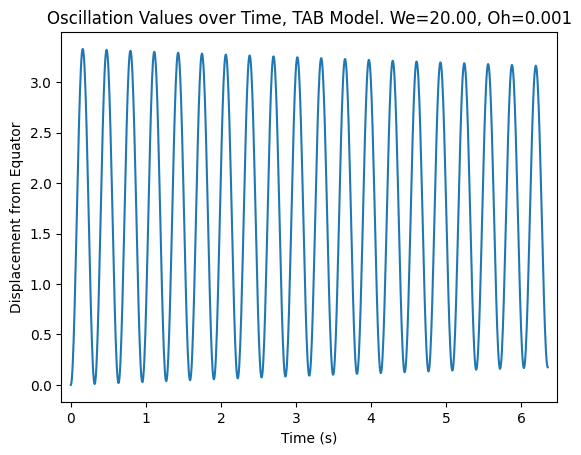

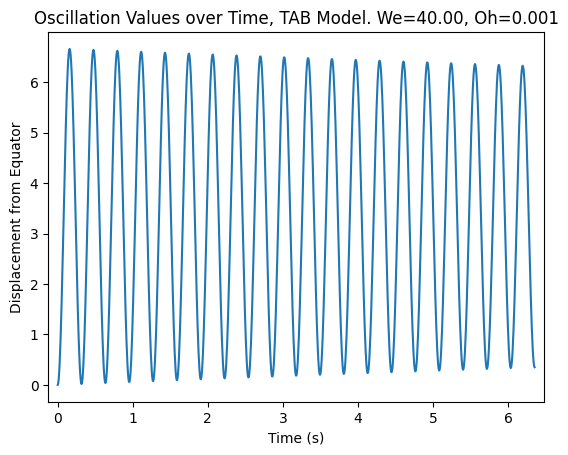

0.013362028401798707


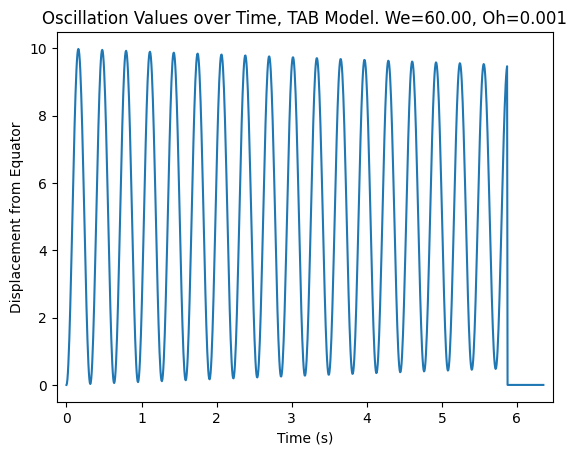

0.013362028401798707


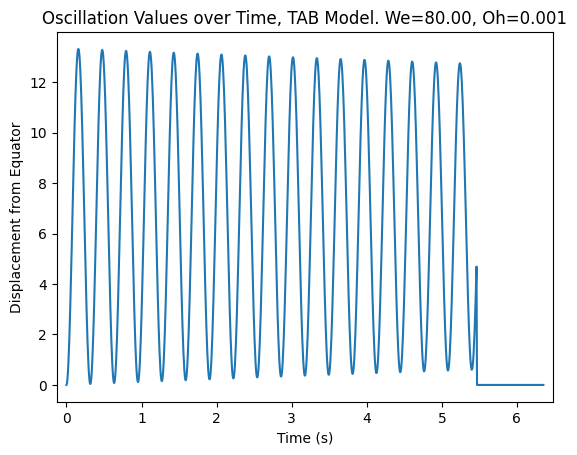

0.013362028401798707


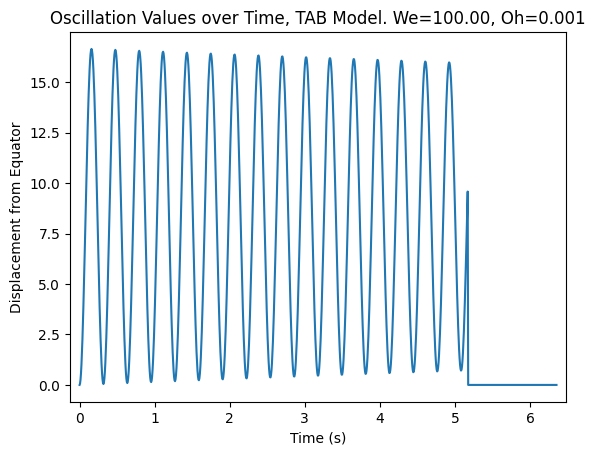

0.013362028401798707


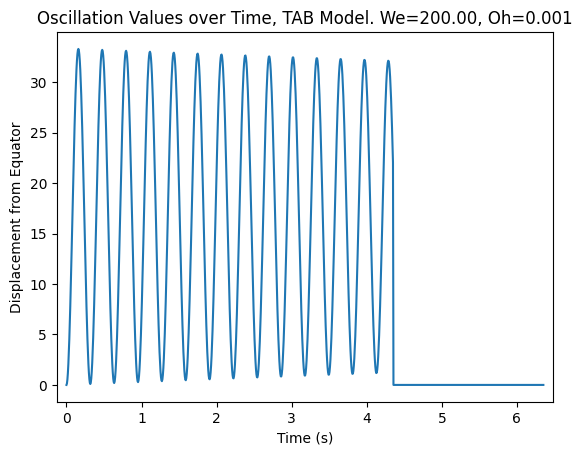

0.013362028401798707


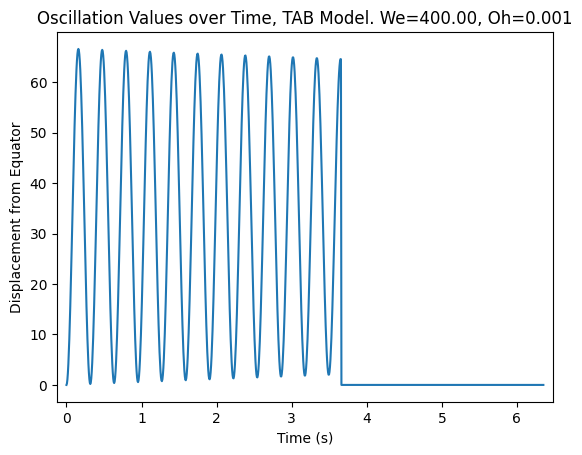

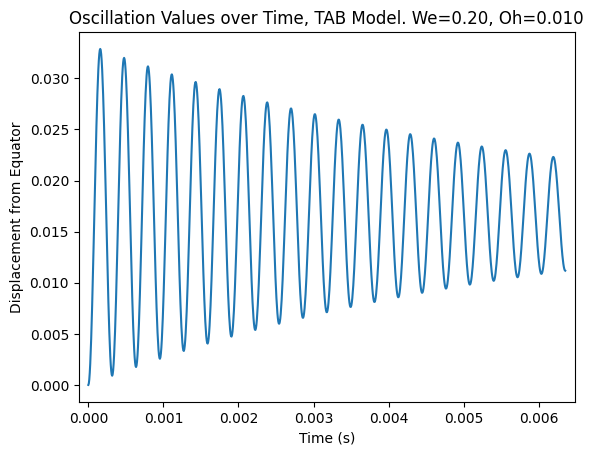

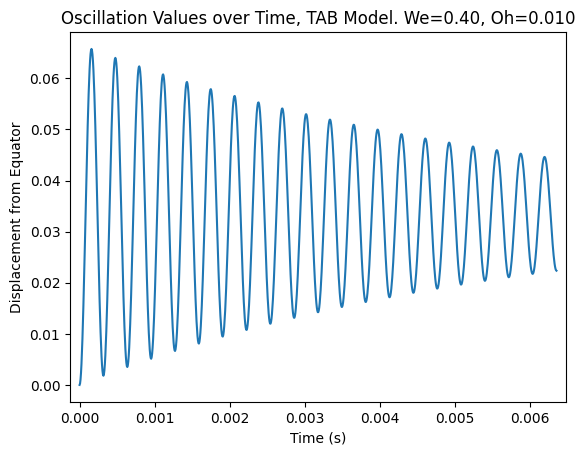

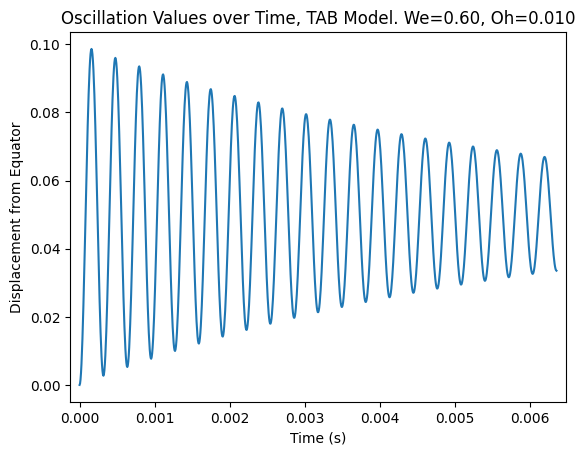

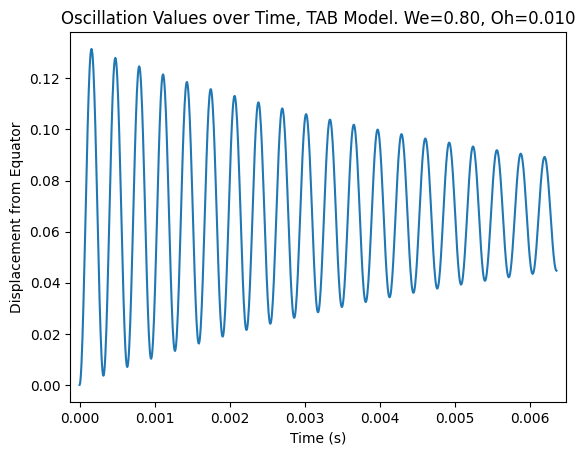

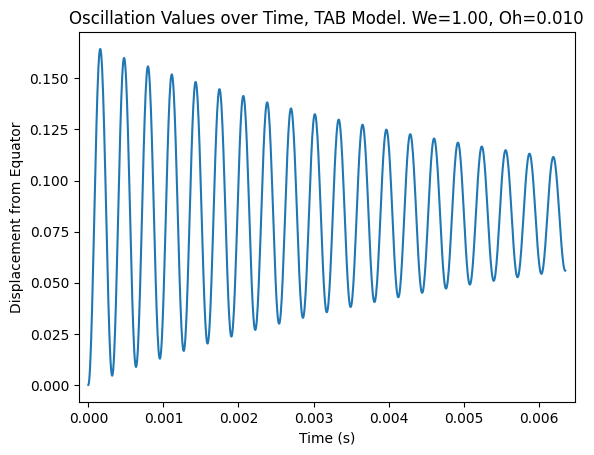

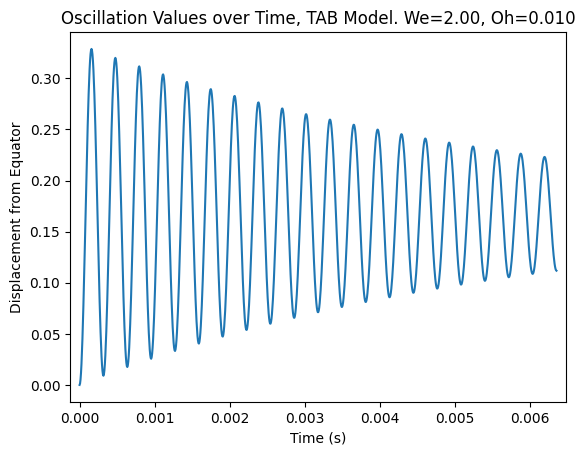

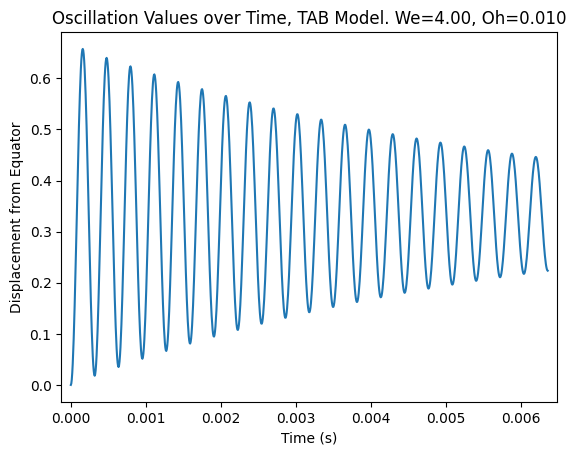

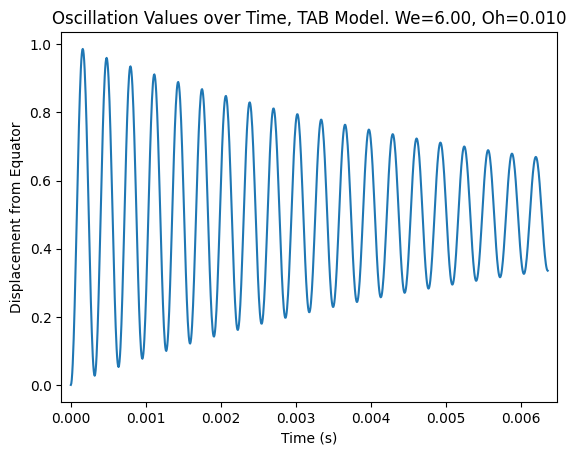

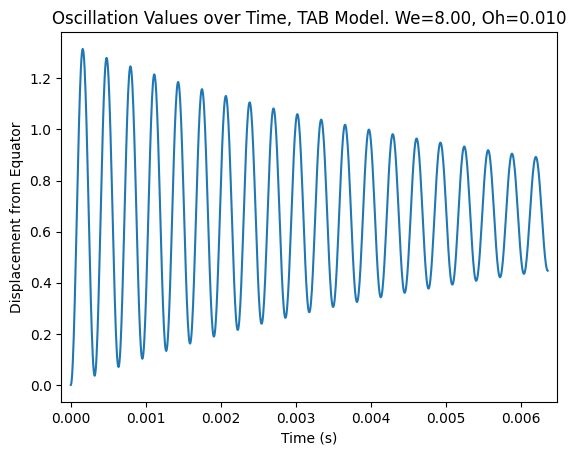

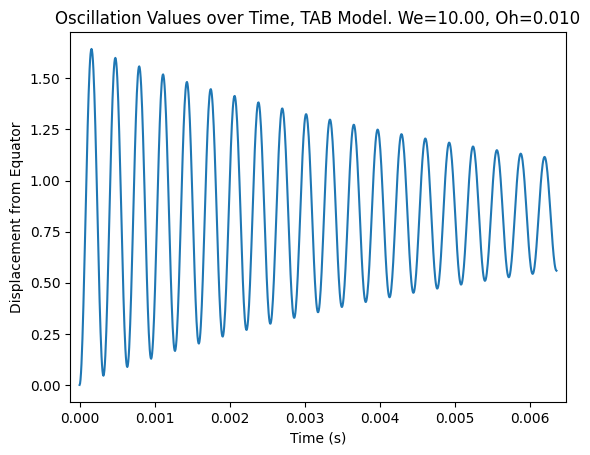

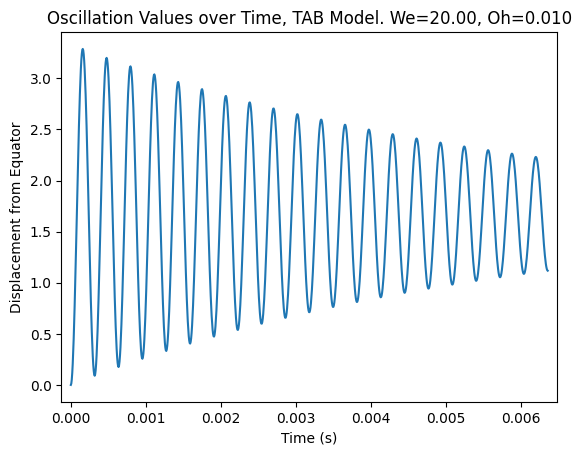

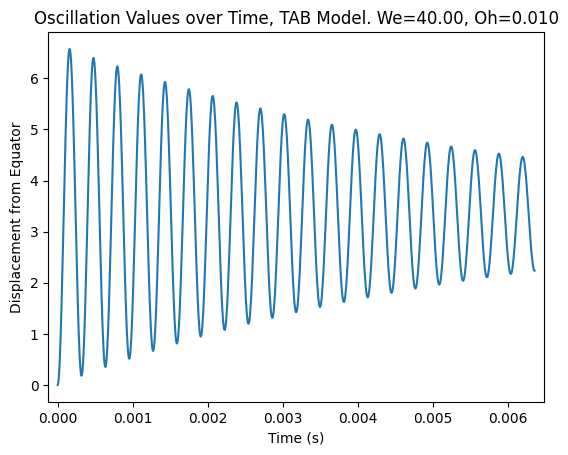

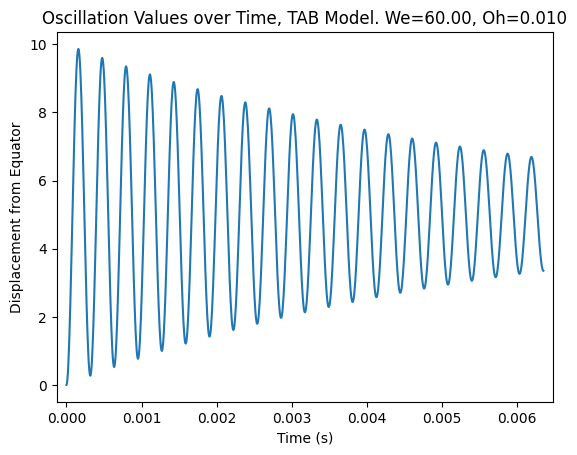

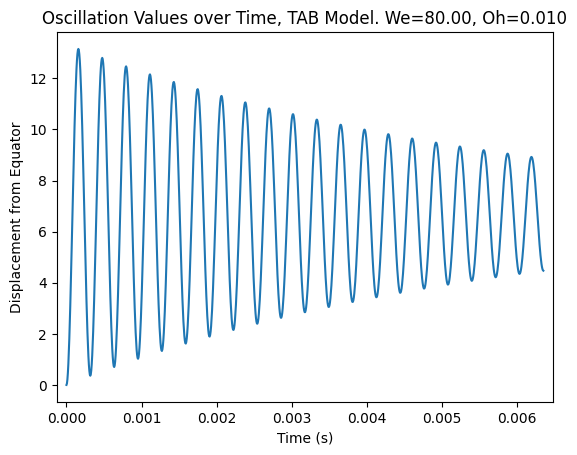

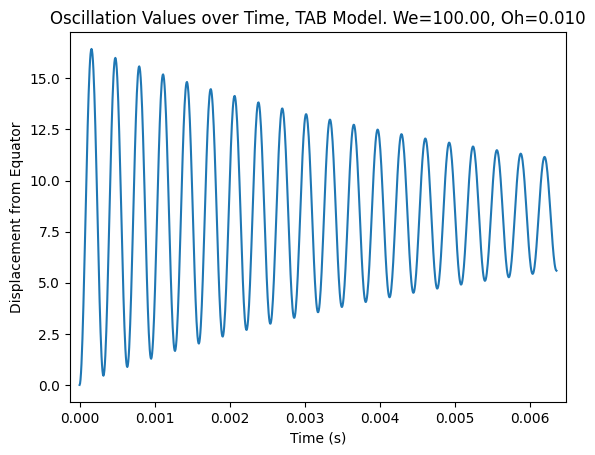

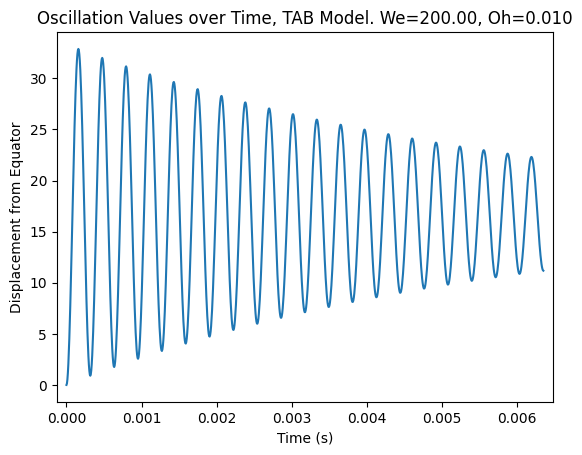

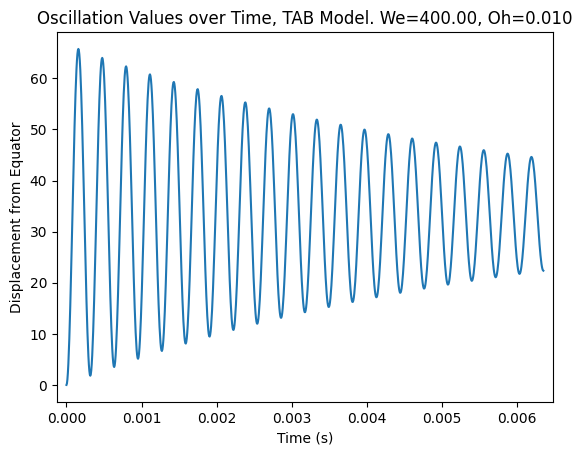

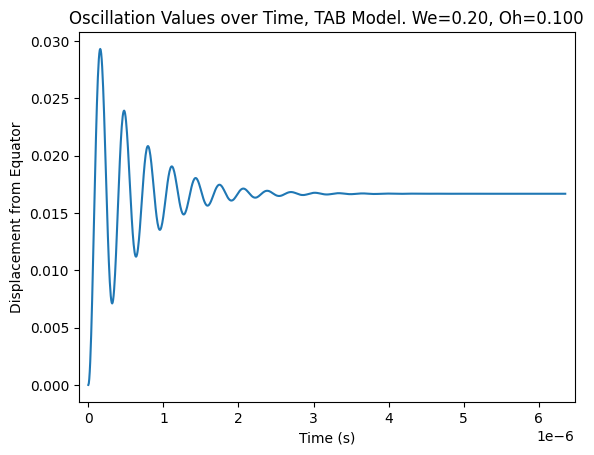

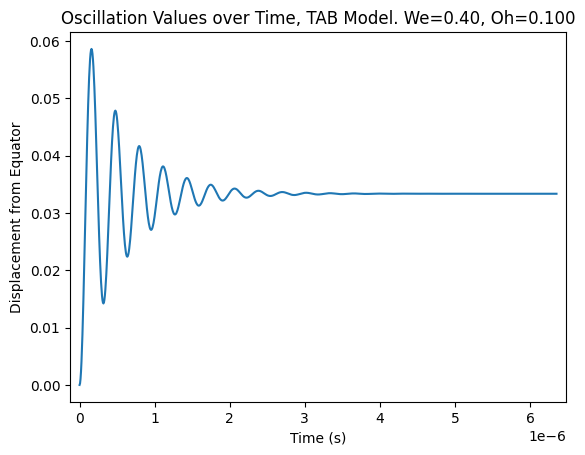

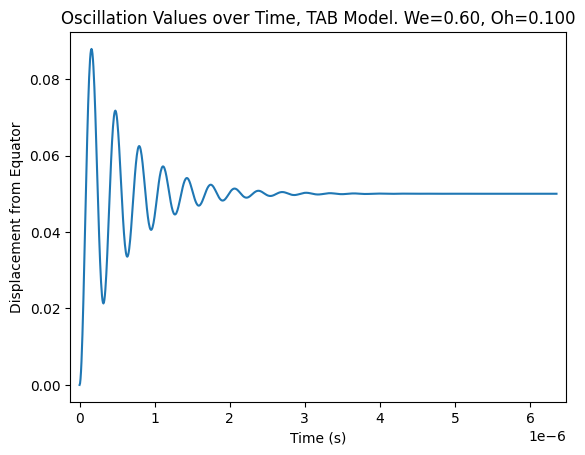

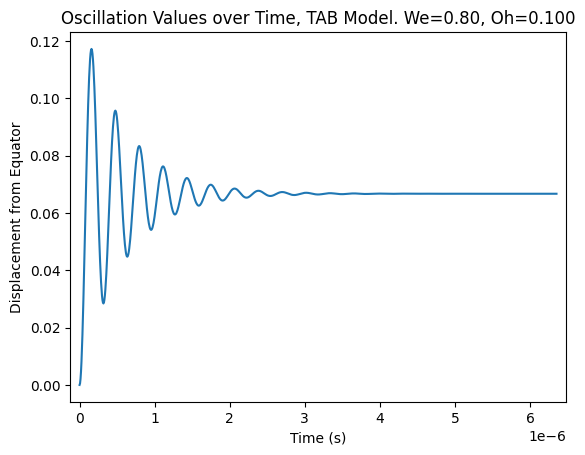

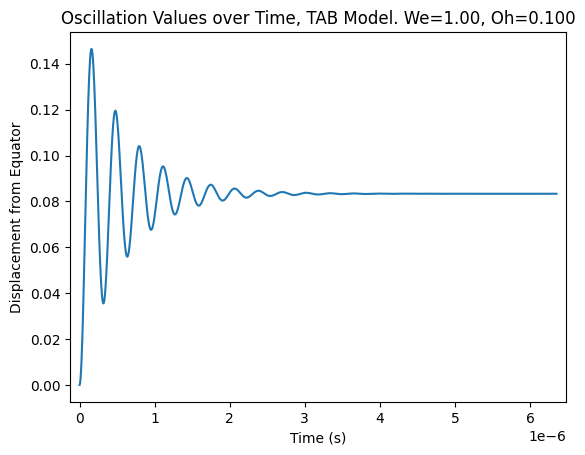

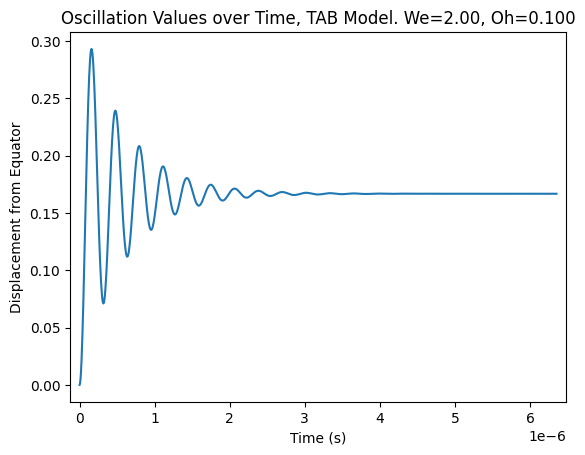

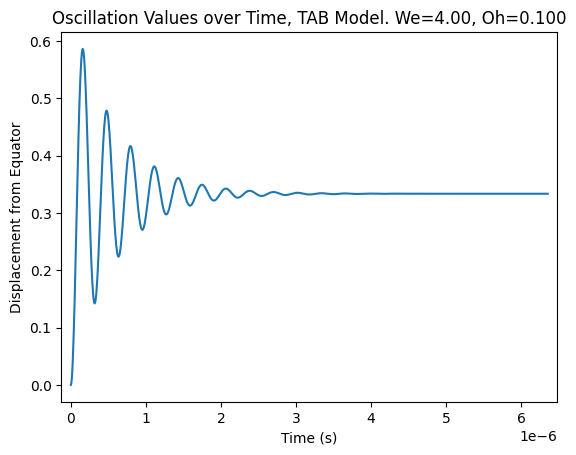

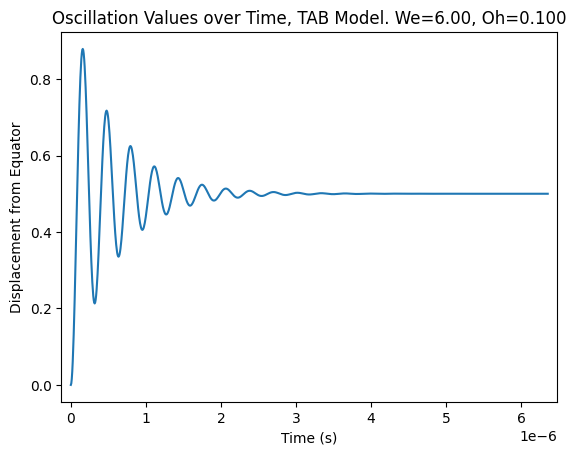

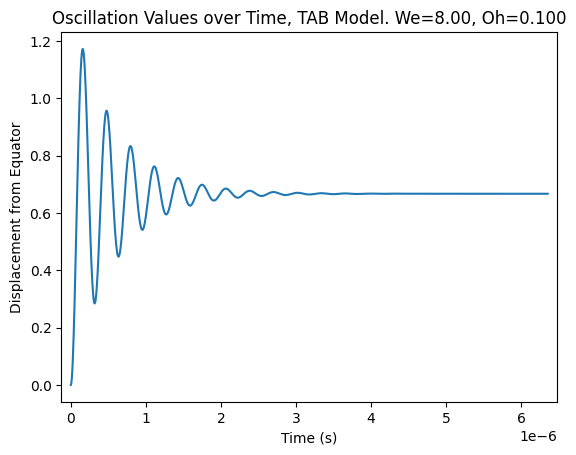

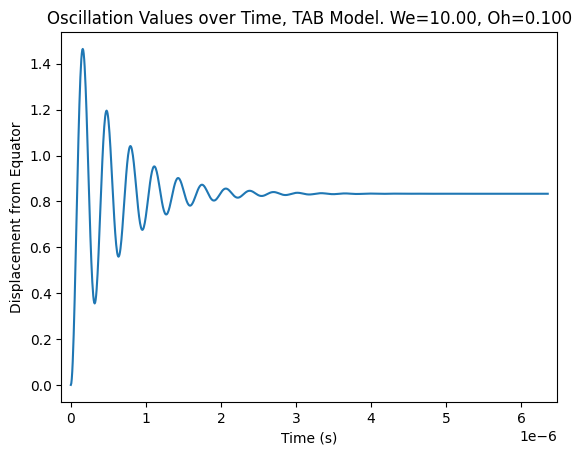

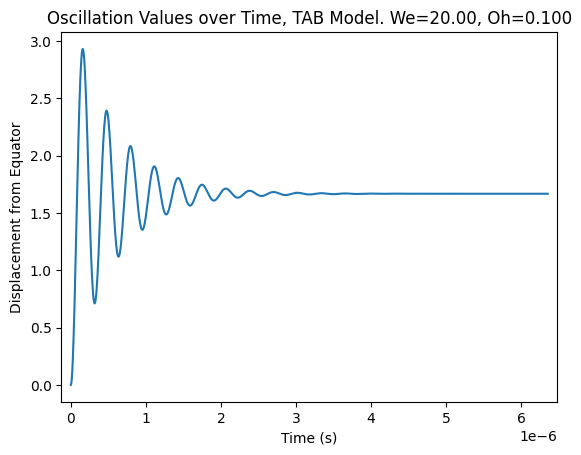

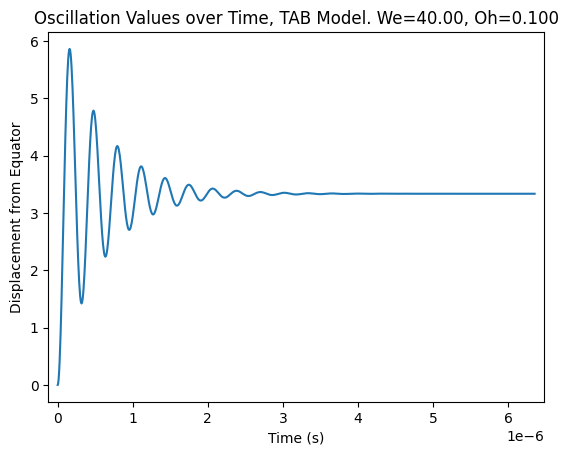

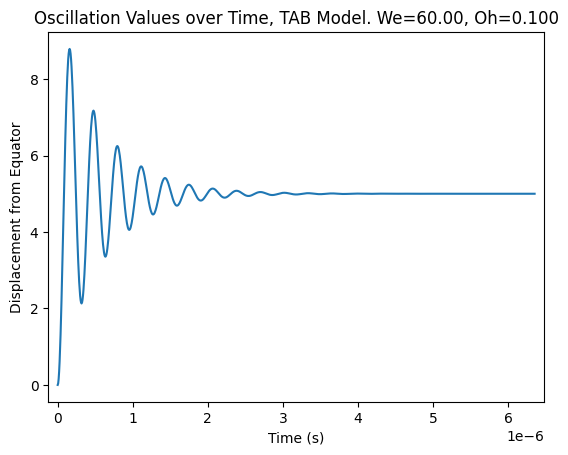

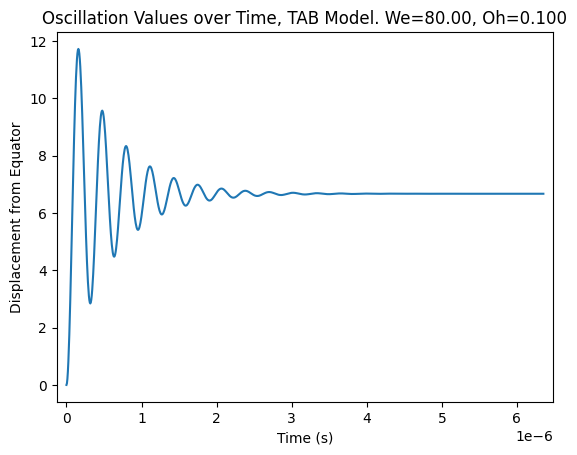

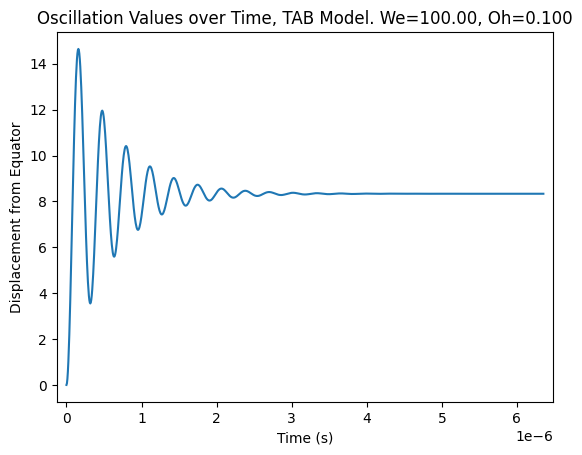

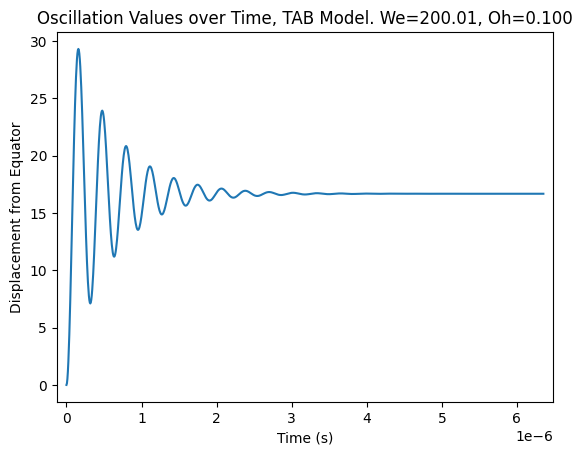

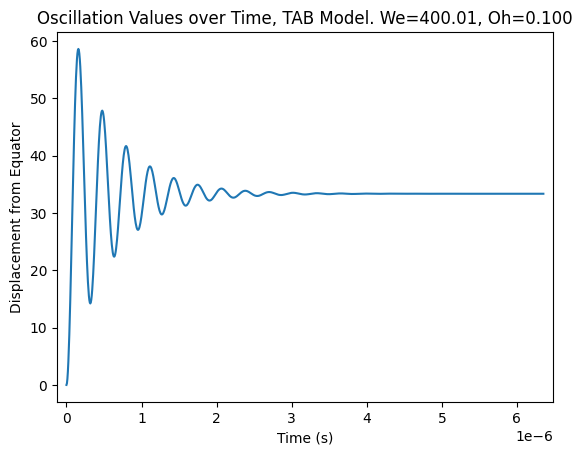

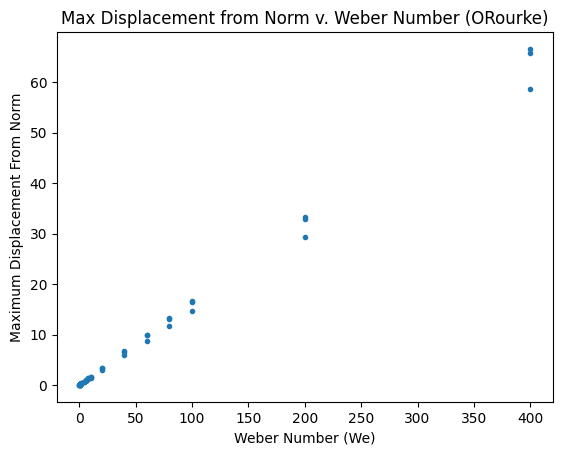

Regime Classifications: ['5' '1' '1' '2' '2' 'o' 'o' 'b' 'b' 'b' 'b' 'b' 'b' 'b' 'b' 'b' 'b' '5'
 '1' '1' '2' '2' 'o' 'o' 'b' 'b' 'b' 'b' 'b' 'b' 'b' 'b' 'b' 'b' '5' '1'
 '1' '2' '2' '>' 'o' 'b' 'b' 'b' 'b' 'b' 'b' 'b' 'b' 'b' 'b']


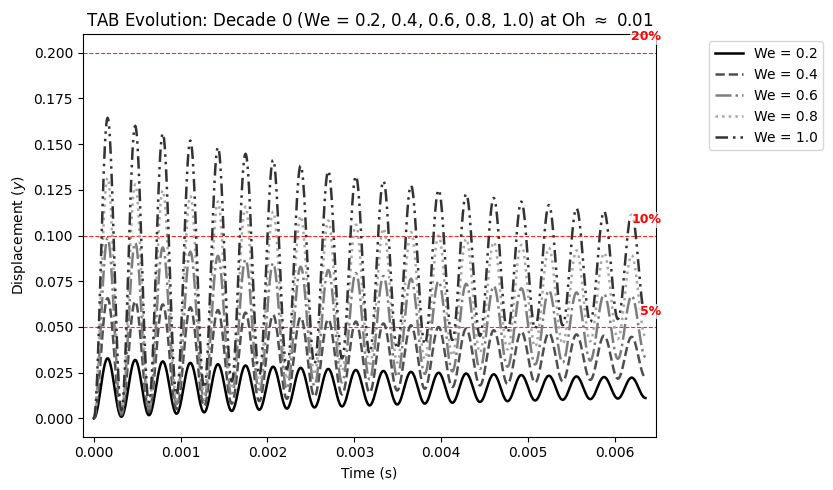

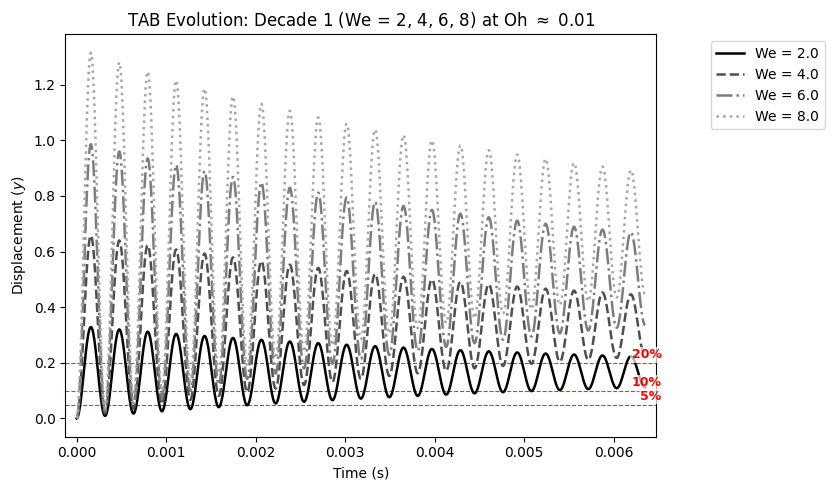

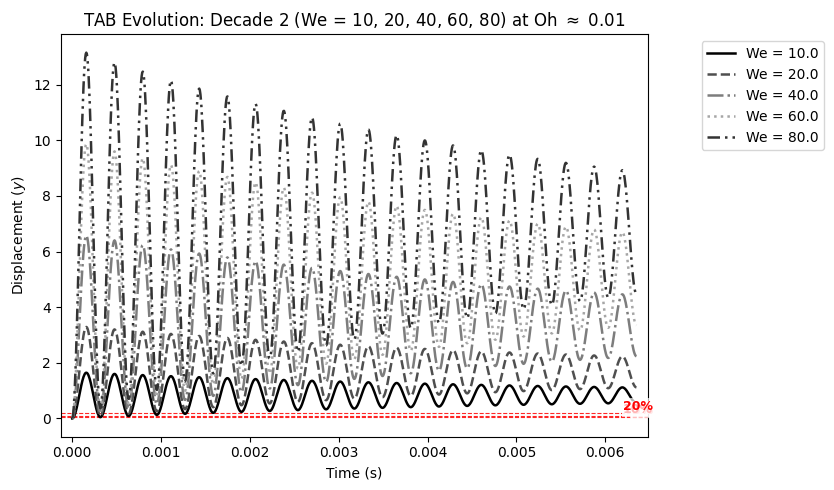

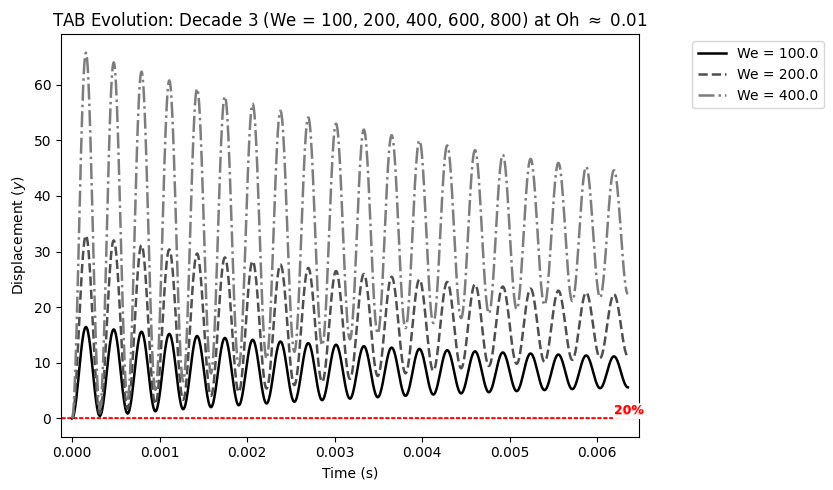

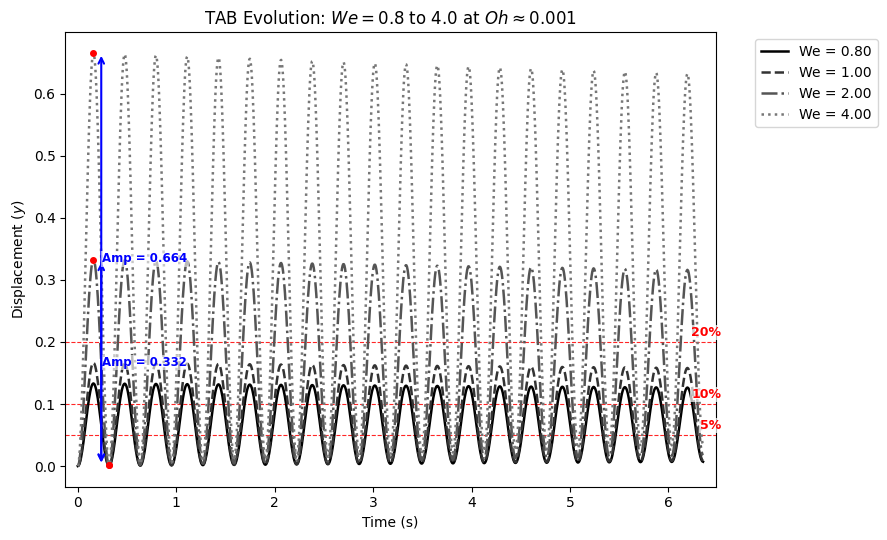

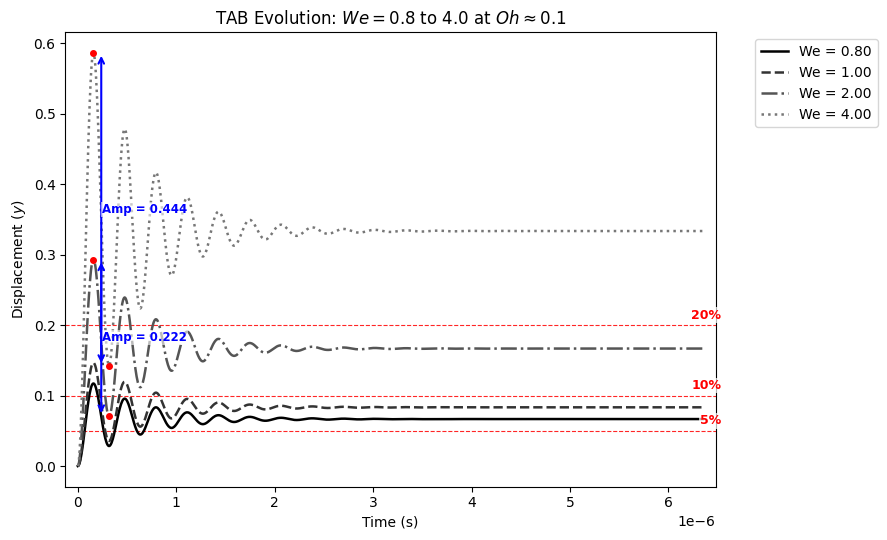

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# --- INITIALIZATION AND STORAGE ---
max_y_val_or = np.zeros(len(radius_values))  # array for max normalized displacement from sphere
We_or = np.zeros(len(radius_values))         # array for all the Weber numbers
regimes_Or = np.empty(len(radius_values), dtype=str)

# Storage dictionaries to hold time-series data for the decade plots
sim_results = []

for k in range(len(radius_values)):

    # All constants and initial conditions are defined here
    y_0 = 0      # initial displacement (starts as a perfect sphere)
    y_dot_0 = 0  # initial displacement velocity

    Cf = 1/3     # force constant
    Ck = 8       # linear constant
    Cd = 5       # damping constant
    Cb = 1/2     # breakup constant

    # These values may be changed:
    rho_g = 1.18  # kg/m^3, density of gaseous ethylene
    rho_l = 997   # kg/m^3, density of liquid
    r = radius_values[k]  # m, radius of droplet
    sigma = 0.0708  # kg/s^2, surface tension
    u = velocity_values[k]  # m/s, velocity

    mu_l = 0.000894  # Pa*s, the dynamic viscosity of Jet A
    t_bu = 8*np.sqrt(rho_l*r/(rho_g*u))  # breakup time of particle

    Oh = mu_l/np.sqrt(rho_l*r*sigma)  # Ohnesorge number
    We = rho_g*(u**2)*r/sigma         # Weber number
    We_or[k] = We

    omega = np.sqrt(Ck*sigma/(rho_l*r**3))  # oscillation frequency

    duration = 20*(2*np.pi/omega)  # seconds, the time we want to watch this particle
    len_t = 1000  # length of time vector

    dt = np.linspace(0, duration, len_t)  # s, time vector
    timestep = dt[1]-dt[0]  # timestep, in seconds

    t_d = (2/Cd)*(rho_l*r**2/mu_l)

    # define size of array beforehand
    y_vals = np.zeros(len_t)  # array for normalized displacements over time
    y_dot_vals = np.zeros(len_t)  # array for normalized change in displacement over time

    y_vals[0] = y_0
    y_dot_vals[0] = y_dot_0
    volume = (4/3)*np.pi*r**3  # constant

    breakup_time = 0  # Breakup time
    breakup_iteration = len_t - 1

    for i in range(len_t-1):

        # Defining some terms which show up frequently
        s = np.sin(omega*timestep)
        c = np.cos(omega*timestep)
        ex = np.exp(-timestep/t_d)
        y_We12 = y_vals[i] - We/12

        y_vals[i+1] = (We/12) + ex*((y_We12)*c + (1/omega)*(y_dot_vals[i] + (y_We12/t_d))*s)
        y_dot_vals[i+1] = (((We/12) - y_vals[i+1])/t_d) + omega*ex*((1/omega)*(y_dot_vals[i] + (y_We12/t_d))*c - (y_We12)*s)

        max_y_val = max(y_vals)
        if (max_y_val + (We/12) > 1) and (dt[i] > t_bu):

            breakup_time = np.pi*np.sqrt((rho_l*r**3)/80)
            print(breakup_time)
            breakup_iteration = i
            num_drops = 13  # 13 new drops

            r_new = ((volume/num_drops)*(3/4)*(1/np.pi))**(1/3)
            Cv = 1
            spray_angle = 2*np.arctan(Cv*(np.sqrt(3)/3))*np.sqrt(rho_g/rho_l)
            vel_new = abs(Cv*Cb*r*y_dot_vals[i])

            b = np.sqrt(abs((r**3)/(r - (y_vals[i])*r))) #This needs to be fixed its na for we=60 0.001, abs is a patch

            new_ypos = np.zeros(num_drops)
            new_zpos = np.zeros(num_drops)
            new_xvel = np.zeros(num_drops)
            new_yvel = np.zeros(num_drops)
            new_zvel = np.zeros(num_drops)

            for j in range(num_drops):

                drop_angle = 2*np.pi*j/num_drops

                new_ypos[j] = b*np.sin(drop_angle)
                new_zpos[j] = b*np.cos(drop_angle)

                new_xvel[j] = vel_new*np.cos(spray_angle)
                new_yvel[j] = vel_new*np.sin(spray_angle)*np.sin(drop_angle)
                new_zvel[j] = vel_new*np.sin(spray_angle)*np.cos(drop_angle)

            break

    # Save data for post-processed multi-line decade plots
    # If breakup occurred, truncate the plot arrays at the breakup point to keep plots clean
    sim_results.append({
        'We': We,
        'Oh': Oh,
        't': dt[:breakup_iteration+1],
        'y': y_vals[:breakup_iteration+1]
    })
    
    peak_indices, _ = find_peaks(y_vals)
    trough_indices, _ = find_peaks(-y_vals) # Detect local minima
    peak_values = y_vals[peak_indices]

    if len(peak_indices) > 0 and len(trough_indices) > 0:
            # The amplitude of the first full oscillation cycle
            oscillation_amplitude = y_vals[peak_indices[0]] - y_vals[trough_indices[0]]
    else:
        oscillation_amplitude = 0.0

    if np.max(y_vals) <= 0.05:
        regimes_Or[k] = '5'
    elif np.max(y_vals) <= 0.1:
        regimes_Or[k] = '10'
    elif np.max(y_vals) <= 0.2:
        regimes_Or[k] = '20'
    elif np.max(y_vals)+(We/12) <= 1 and oscillation_amplitude < 0.25:
        regimes_Or[k] = '>20'
    elif np.max(y_vals)+(We/12) <= 1:
        regimes_Or[k] = 'osc'
    else:
        regimes_Or[k] = 'brk'

    # --- 1. INDIVIDUAL PLOTS WITH DYNAMIC AUTO-SCALING ---
    plt.figure()
    plt.plot(dt, y_vals, label='$y(t)$')
    plt.title(f'Oscillation Values over Time, TAB Model. We={We:.2f}, Oh={Oh:.3f}')
    plt.xlabel('Time (s)')
    plt.ylabel('Displacement from Equator')
    
    # Enable tight auto-scaling with a small percentage margin to eliminate excess whitespace
    plt.autoscale(enable=True, axis='both', tight=None)
    plt.margins(x=0.02, y=0.05) 
    plt.show()

    max_y_val_or[k] = np.max(y_vals)

# --- BASELINE DIAGNOSTIC PLOT ---
plt.figure()
plt.plot(We_or, max_y_val_or, '.')
plt.title('Max Displacement from Norm v. Weber Number (ORourke)')
plt.xlabel('Weber Number (We)')
plt.ylabel('Maximum Displacement From Norm')
plt.margins(x=0.05, y=0.05)
plt.show()

print("Regime Classifications:", regimes_Or)


# --- 2. MULTI-LINE DECADE GROUPED PLOTS BY TARGET OH (BLACK & WHITE FRIENDLY) ---
# Updated decades dictionary to include Decade 0 (We = 0.2 to 1.0)
decades = {
    "Decade 0 (We = 0.2, 0.4, 0.6, 0.8, 1.0)": [0.2, 0.4, 0.6, 0.8, 1.0],
    "Decade 1 (We = 2, 4, 6, 8)": [2, 4, 6, 8],
    "Decade 2 (We = 10, 20, 40, 60, 80)": [10, 20, 40, 60, 80],
    "Decade 3 (We = 100, 200, 400, 600, 800)": [100, 200, 400, 600, 800]
}

# Define target Ohnesorge number for grouping (e.g., Oh = 0.001)
target_Oh = 0.01
oh_tolerance = 0.0005  # Tolerance window to group closely matched Oh numbers

# High-contrast, black-and-white friendly styles for printing
linestyles = ['-', '--', '-.', ':', (0, (5, 2, 1, 2, 1, 2))]
grayscale_colors = ['#000000', '#4f4f4f', '#7d7d7d', '#a6a6a6', '#333333']

for decade_name, target_We_list in decades.items():
    fig, ax = plt.subplots(figsize=(8.5, 5))
    lines_plotted = 0
    
    for res in sim_results:
        # Check if run belongs to target Oh cluster
        if np.isclose(res['Oh'], target_Oh, atol=oh_tolerance):
            # Check if We matches target values in this decade
            if any(np.isclose(res['We'], target_val, rtol=0.05) for target_val in target_We_list):
                
                style = linestyles[lines_plotted % len(linestyles)]
                color = grayscale_colors[lines_plotted % len(grayscale_colors)]
                
                ax.plot(
                    res['t'], 
                    res['y'], 
                    linestyle=style, 
                    color=color, 
                    linewidth=1.8,
                    label=f'We = {res["We"]:.1f}'
                )
                lines_plotted += 1
                
    if lines_plotted > 0:
        # --- RED HORIZONTAL THRESHOLD LINES & INLINE LABELS ---
        y_thresholds = [0.05, 0.1, 0.2]
        labels = ["5%", "10%", "20%"]
        
        # Get x-axis boundaries for text placement
        x_min, x_max = ax.get_xlim()
        
        for y_val, label_text in zip(y_thresholds, labels):
            # Add thin red horizontal line across the plot
            ax.axhline(y=y_val, color='red', linestyle='--', linewidth=0.8, alpha=0.85, zorder=1)
            
            # Place label at the right end of the line
            ax.text(
                x_max * 0.98, y_val + 0.005, label_text, 
                color='red', fontsize=9, fontweight='bold', 
                ha='right', va='bottom', zorder=5,
                bbox=dict(boxstyle='square,pad=0.1', facecolor='white', edgecolor='none', alpha=0.7)
            )

        ax.set_title(f'TAB Evolution: {decade_name} at Oh $\\approx$ {target_Oh}')
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Displacement ($y$)')
        ax.legend(bbox_to_anchor=(1.08, 1), loc='upper left')
        ax.margins(x=0.02, y=0.05)
        plt.tight_layout()
        plt.show()
    else:
        plt.close(fig) # Close empty plots if no matching runs are found
       

# --- STANDALONE PLOT: We = 0.8 TO 4.0 AT Oh ≈ 0.001 WITH AMP FOR We=2 & We=4 ---
target_Oh = 0.001        # Target Ohnesorge cluster
oh_tolerance = 0.0005    # Window around target Oh

# Filter results for We between 0.8 and 4.0 at Oh ~ 0.001
we_min, we_max = 0.8, 4.0
target_runs = [
    res for res in sim_results 
    if np.isclose(res['Oh'], target_Oh, atol=oh_tolerance) 
    and (we_min - 0.05 <= res['We'] <= we_max + 0.05)
]

# Sort runs by Weber number so plotting order remains clean
target_runs.sort(key=lambda x: x['We'])

if target_runs:
    fig, ax = plt.subplots(figsize=(9, 5.5))
    
    linestyles = ['-', '--', '-.', ':', (0, (5, 2, 1, 2, 1, 2))]
    grayscale_colors = ['#000000', '#333333', '#555555', '#777777', '#999999', '#bbbbbb']
    
    # We explicitly want amplitude arrows for We close to 2 and 4
    target_amp_we_list = [2.0, 4.0]

    for idx, res in enumerate(target_runs):
        style = linestyles[idx % len(linestyles)]
        color = grayscale_colors[idx % len(grayscale_colors)]
        
        ax.plot(
            res['t'], 
            res['y'], 
            linestyle=style, 
            color=color, 
            linewidth=1.8,
            label=f'We = {res["We"]:.2f}'
        )
        
        # --- HIGHLIGHT OSCILLATION AMPLITUDES FOR WE = 2 AND WE = 4 ---
        if any(np.isclose(res['We'], target_we, rtol=0.1) for target_we in target_amp_we_list):
            y_vals_curve = res['y']
            t_vals_curve = res['t']
            
            peaks, _ = find_peaks(y_vals_curve)
            troughs, _ = find_peaks(-y_vals_curve)
            
            if len(peaks) > 0 and len(troughs) > 0:
                t_p1, y_p1 = t_vals_curve[peaks[0]], y_vals_curve[peaks[0]]
                t_t1, y_t1 = t_vals_curve[troughs[0]], y_vals_curve[troughs[0]]
                
                # Plot red dots at Peak 1 and Trough 1
                ax.plot(t_p1, y_p1, 'ro', markersize=4, zorder=6)
                ax.plot(t_t1, y_t1, 'ro', markersize=4, zorder=6)
                
                # Draw double-headed vertical arrow between Peak 1 and Trough 1
                t_arrow = (t_p1 + t_t1) / 2
                ax.annotate(
                    '', xy=(t_arrow, y_t1), xytext=(t_arrow, y_p1),
                    arrowprops=dict(arrowstyle='<->', color='blue', lw=1.5),
                    zorder=6
                )
                
                # Label the peak-to-trough amplitude
                amp = y_p1 - y_t1
                ax.text(
                    t_arrow * 1.05, (y_p1 + y_t1) / 2, 
                    f'Amp = {amp:.3f}', 
                    color='blue', fontsize=8.5, fontweight='bold', va='center',
                    bbox=dict(boxstyle='square,pad=0.1', facecolor='white', edgecolor='none', alpha=0.6),
                    zorder=6
                )

    # --- RED HORIZONTAL THRESHOLD LINES & INLINE LABELS ---
    y_thresholds = [0.05, 0.1, 0.2]
    labels = ["5%", "10%", "20%"]
    x_min, x_max = ax.get_xlim()
    
    for y_val, label_text in zip(y_thresholds, labels):
        ax.axhline(y=y_val, color='red', linestyle='--', linewidth=0.8, alpha=0.85, zorder=1)
        ax.text(
            x_max * 0.98, y_val + 0.005, label_text, 
            color='red', fontsize=9, fontweight='bold', ha='right', va='bottom', zorder=5,
            bbox=dict(boxstyle='square,pad=0.1', facecolor='white', edgecolor='none', alpha=0.7)
        )

    ax.set_title(f'TAB Evolution: $We = 0.8$ to $4.0$ at $Oh \\approx {target_Oh}$')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Displacement ($y$)')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.margins(x=0.02, y=0.05)
    plt.tight_layout()
    plt.show()

# --- STANDALONE PLOT: We = 0.8 TO 4.0 AT Oh ≈ 0.1 WITH AMP FOR We=2 & We=4 ---
target_Oh = 0.1          # Target Ohnesorge cluster
oh_tolerance = 0.05      # Window around target Oh

# Filter results for We between 0.8 and 4.0 at Oh ~ 0.1
we_min, we_max = 0.8, 4.0
target_runs = [
    res for res in sim_results 
    if np.isclose(res['Oh'], target_Oh, atol=oh_tolerance) 
    and (we_min - 0.05 <= res['We'] <= we_max + 0.05)
]

# Sort runs by Weber number so plotting order remains clean
target_runs.sort(key=lambda x: x['We'])

if target_runs:
    fig, ax = plt.subplots(figsize=(9, 5.5))
    
    linestyles = ['-', '--', '-.', ':', (0, (5, 2, 1, 2, 1, 2))]
    grayscale_colors = ['#000000', '#333333', '#555555', '#777777', '#999999', '#bbbbbb']
    
    # We explicitly want amplitude arrows for We close to 2 and 4
    target_amp_we_list = [2.0, 4.0]

    for idx, res in enumerate(target_runs):
        style = linestyles[idx % len(linestyles)]
        color = grayscale_colors[idx % len(grayscale_colors)]
        
        ax.plot(
            res['t'], 
            res['y'], 
            linestyle=style, 
            color=color, 
            linewidth=1.8,
            label=f'We = {res["We"]:.2f}'
        )
        
        # --- HIGHLIGHT OSCILLATION AMPLITUDES FOR WE = 2 AND WE = 4 ---
        if any(np.isclose(res['We'], target_we, rtol=0.1) for target_we in target_amp_we_list):
            y_vals_curve = res['y']
            t_vals_curve = res['t']
            
            peaks, _ = find_peaks(y_vals_curve)
            troughs, _ = find_peaks(-y_vals_curve)
            
            if len(peaks) > 0 and len(troughs) > 0:
                t_p1, y_p1 = t_vals_curve[peaks[0]], y_vals_curve[peaks[0]]
                t_t1, y_t1 = t_vals_curve[troughs[0]], y_vals_curve[troughs[0]]
                
                # Plot red dots at Peak 1 and Trough 1
                ax.plot(t_p1, y_p1, 'ro', markersize=4, zorder=6)
                ax.plot(t_t1, y_t1, 'ro', markersize=4, zorder=6)
                
                # Draw double-headed vertical arrow between Peak 1 and Trough 1
                t_arrow = (t_p1 + t_t1) / 2
                ax.annotate(
                    '', xy=(t_arrow, y_t1), xytext=(t_arrow, y_p1),
                    arrowprops=dict(arrowstyle='<->', color='blue', lw=1.5),
                    zorder=6
                )
                
                # Label the peak-to-trough amplitude
                amp = y_p1 - y_t1
                ax.text(
                    t_arrow * 1.05, (y_p1 + y_t1) / 2, 
                    f'Amp = {amp:.3f}', 
                    color='blue', fontsize=8.5, fontweight='bold', va='center',
                    bbox=dict(boxstyle='square,pad=0.1', facecolor='white', edgecolor='none', alpha=0.6),
                    zorder=6
                )

    # --- RED HORIZONTAL THRESHOLD LINES & INLINE LABELS ---
    y_thresholds = [0.05, 0.1, 0.2]
    labels = ["5%", "10%", "20%"]
    x_min, x_max = ax.get_xlim()
    
    for y_val, label_text in zip(y_thresholds, labels):
        ax.axhline(y=y_val, color='red', linestyle='--', linewidth=0.8, alpha=0.85, zorder=1)
        ax.text(
            x_max * 0.98, y_val + 0.005, label_text, 
            color='red', fontsize=9, fontweight='bold', ha='right', va='bottom', zorder=5,
            bbox=dict(boxstyle='square,pad=0.1', facecolor='white', edgecolor='none', alpha=0.7)
        )

    ax.set_title(f'TAB Evolution: $We = 0.8$ to $4.0$ at $Oh \\approx {target_Oh}$')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Displacement ($y$)')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.margins(x=0.02, y=0.05)
    plt.tight_layout()
    plt.show()

TANNER MODEL

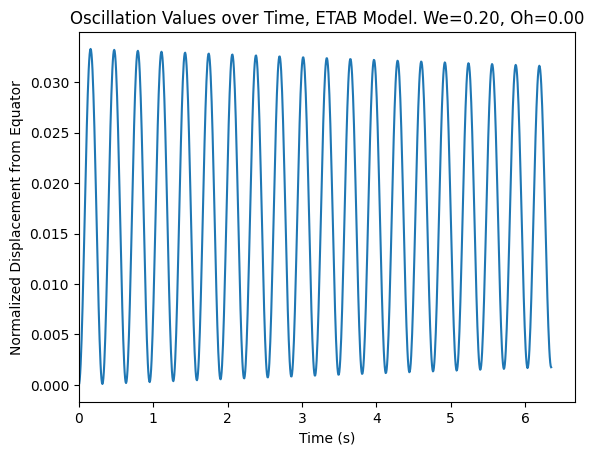

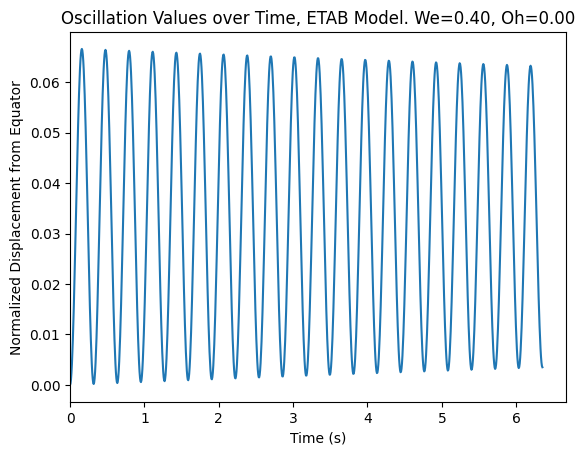

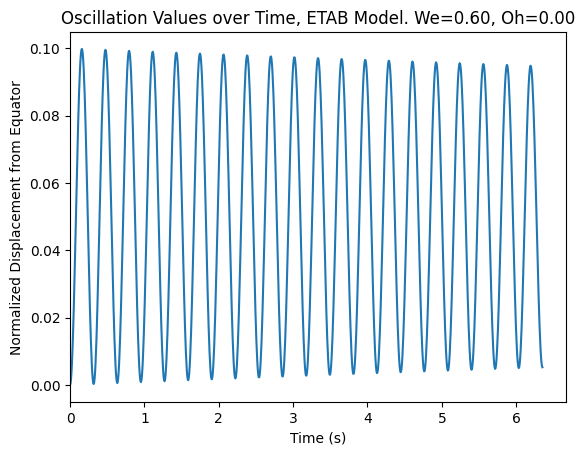

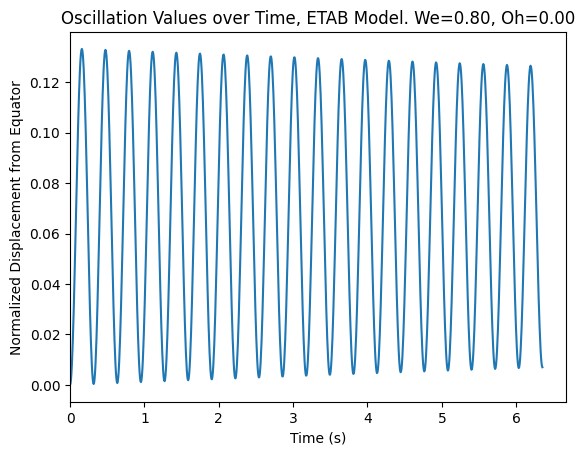

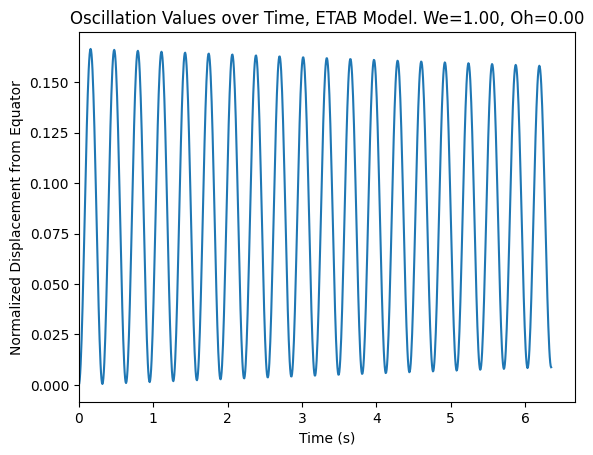

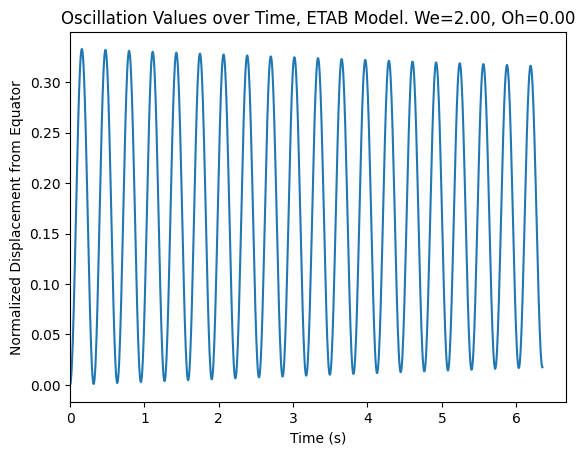

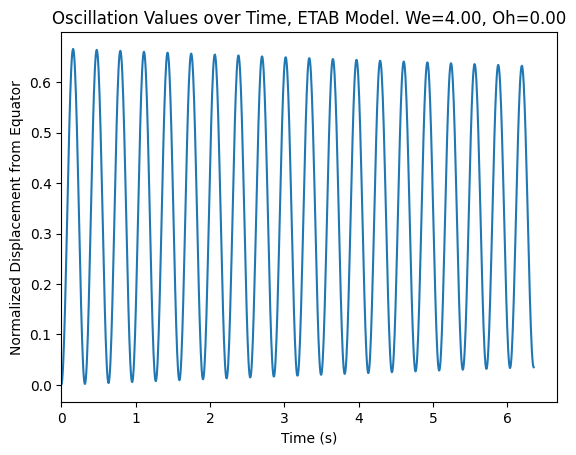

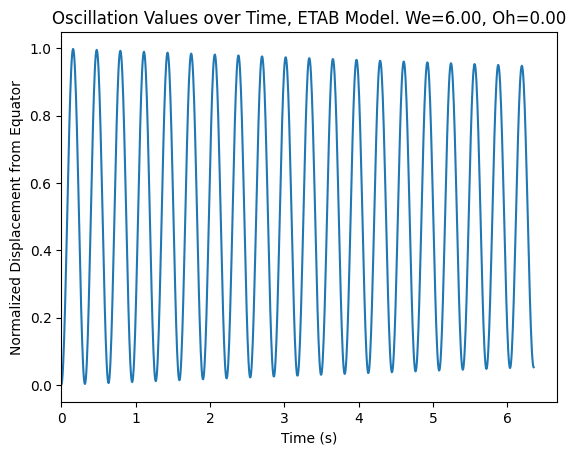

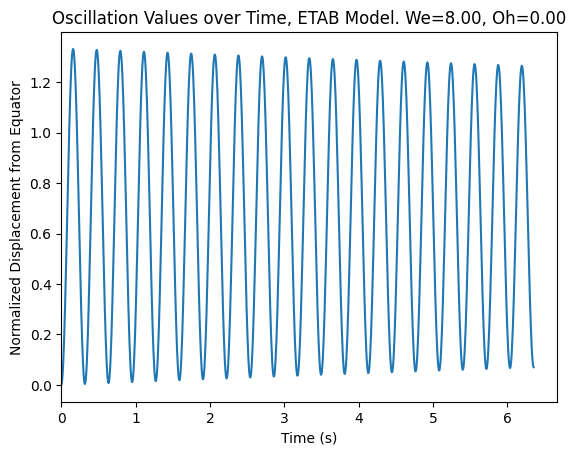

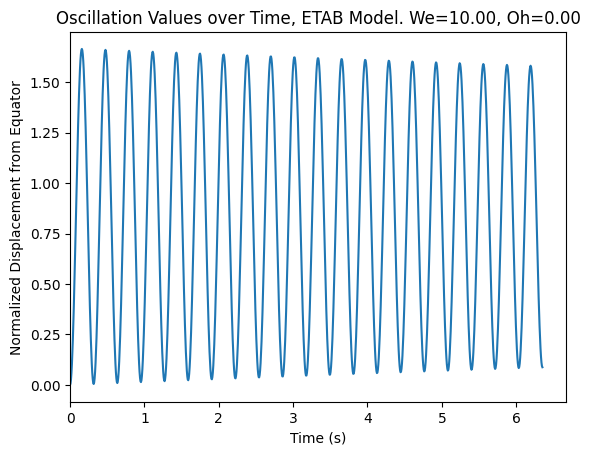

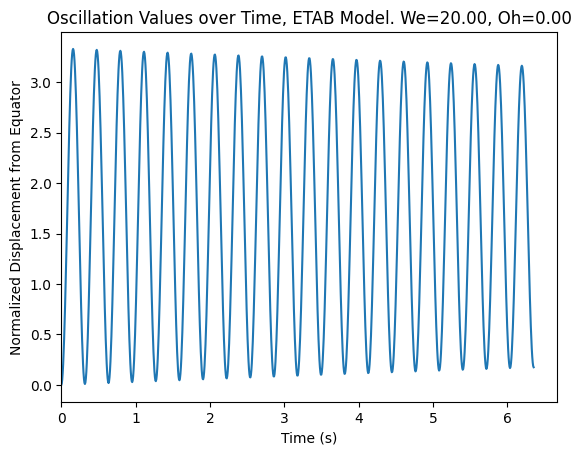

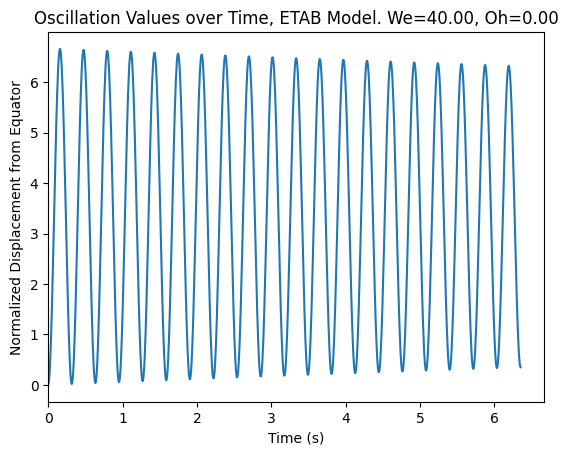

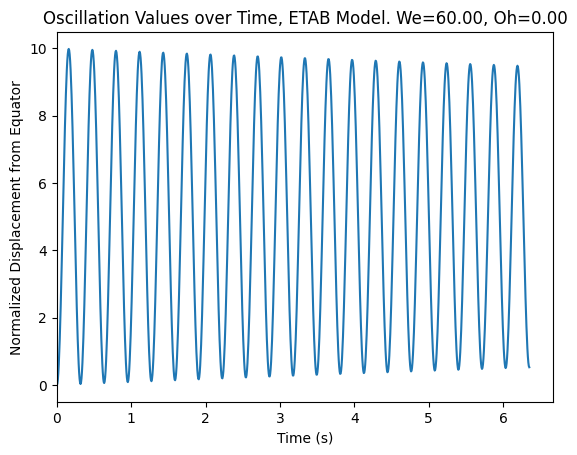

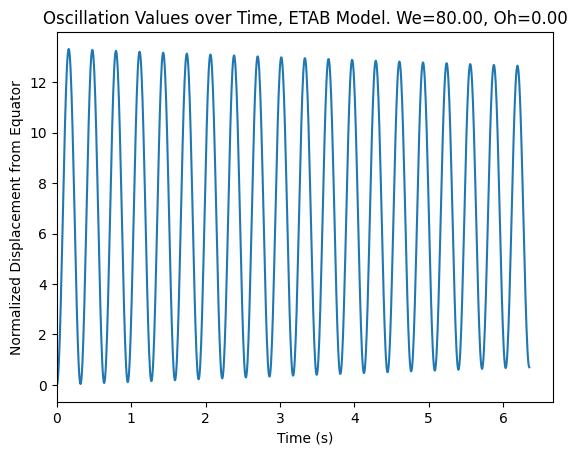

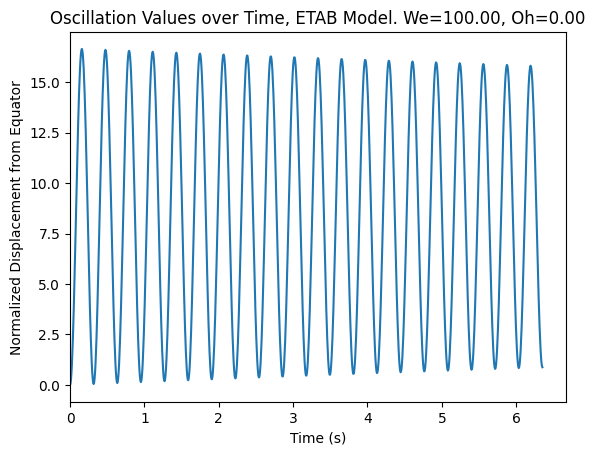

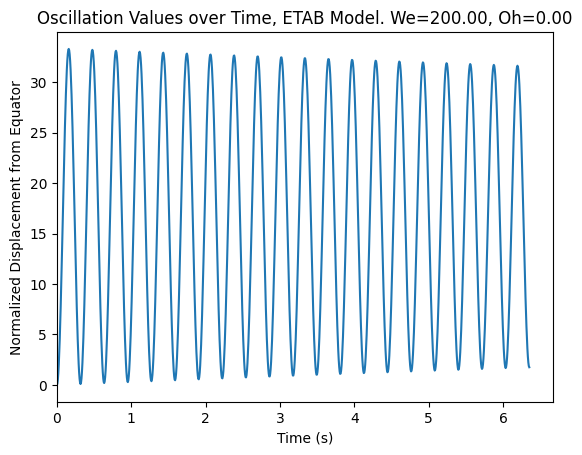

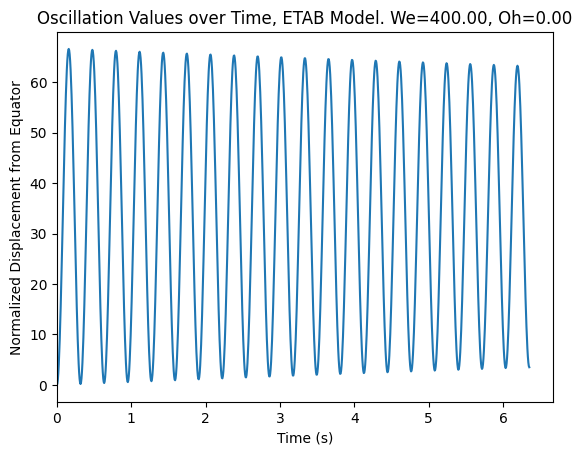

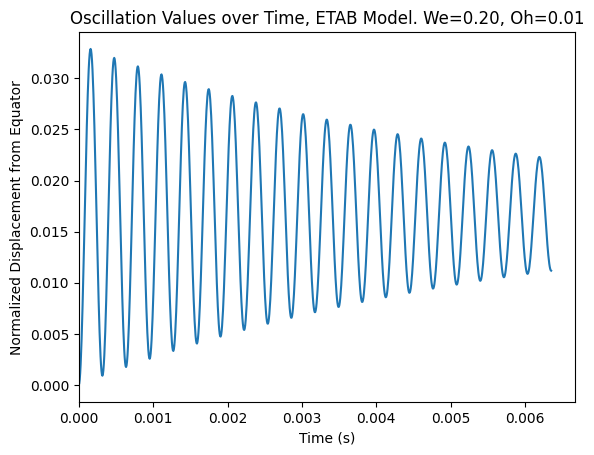

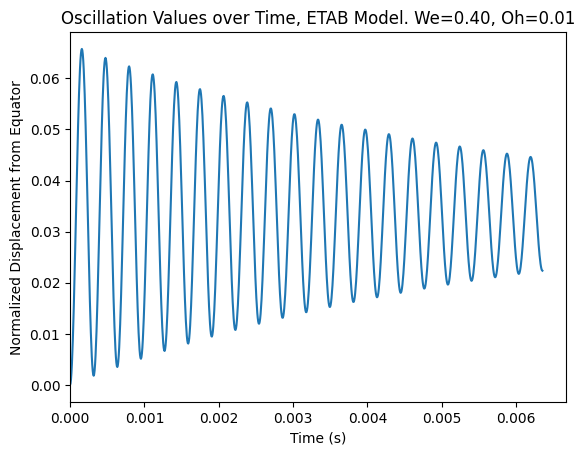

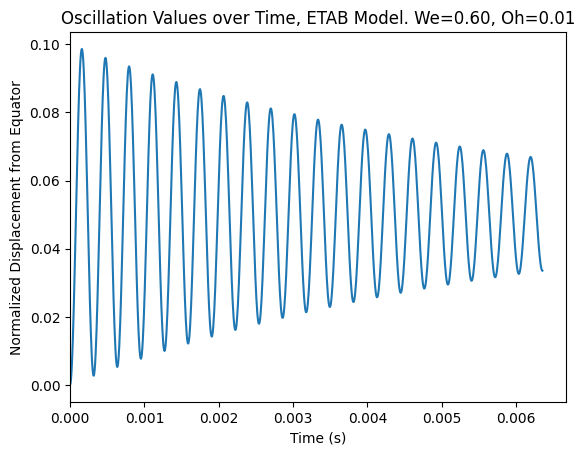

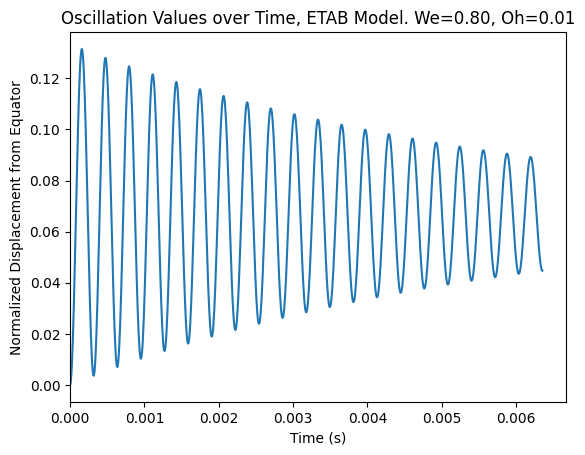

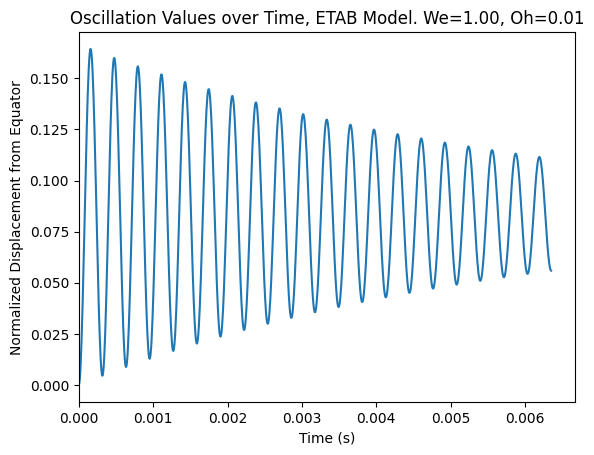

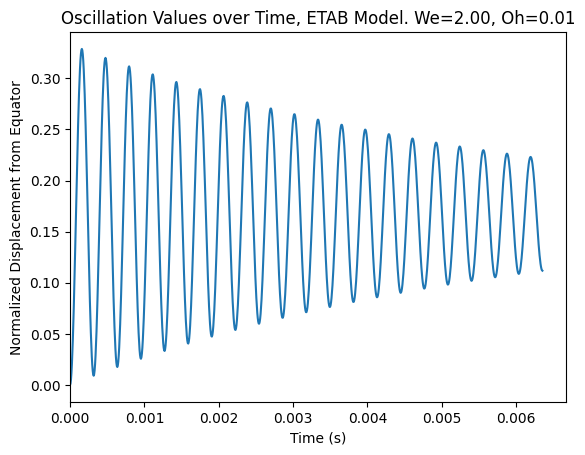

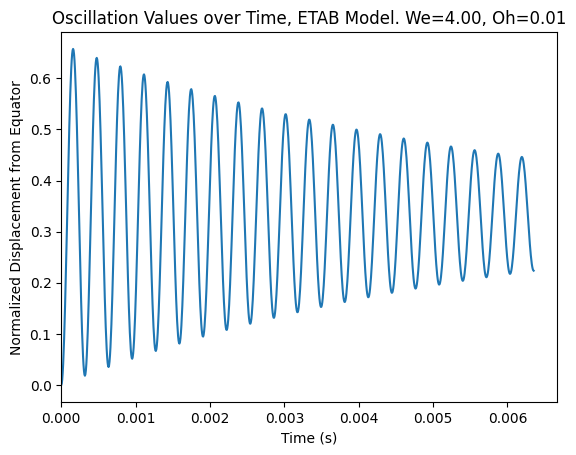

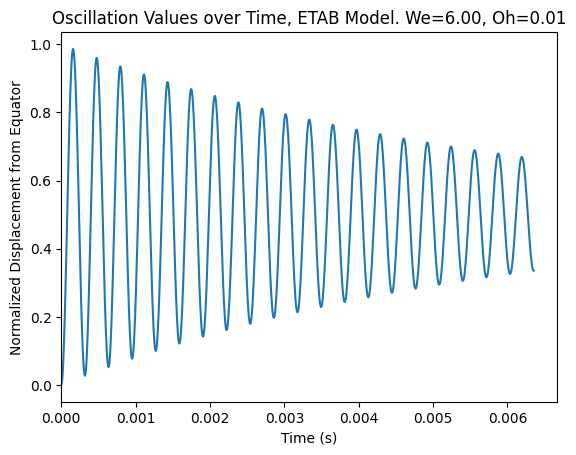

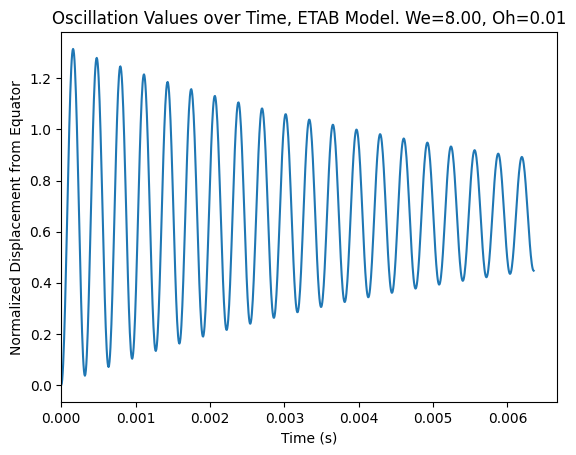

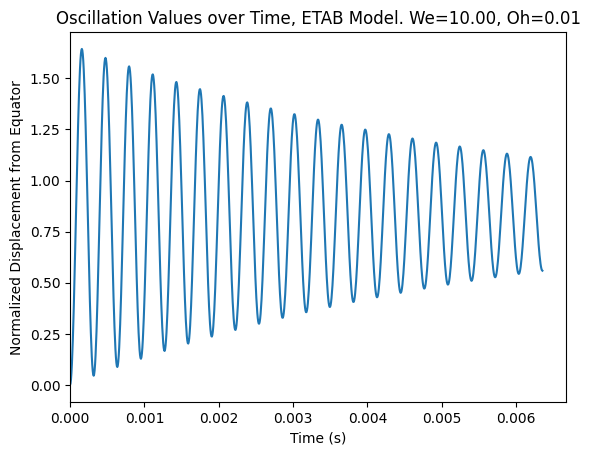

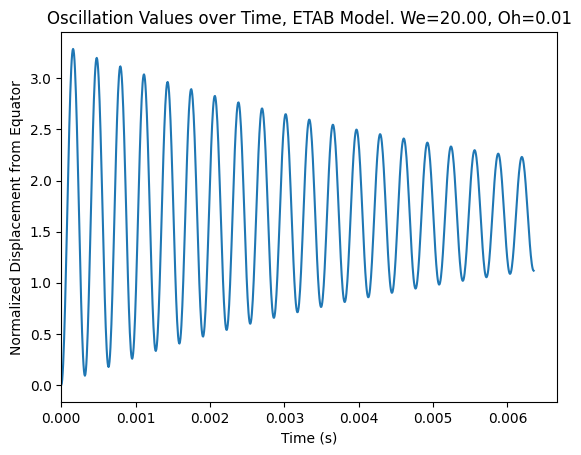

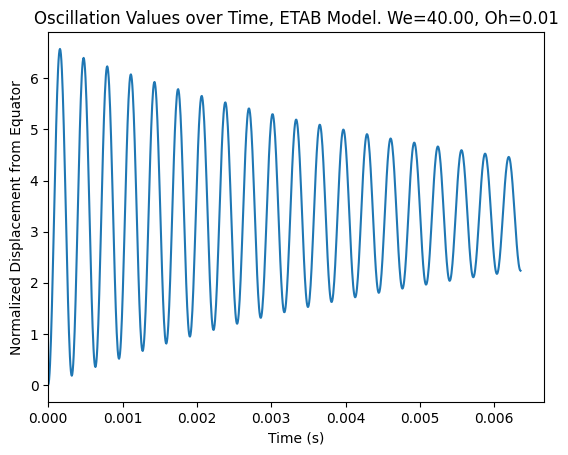

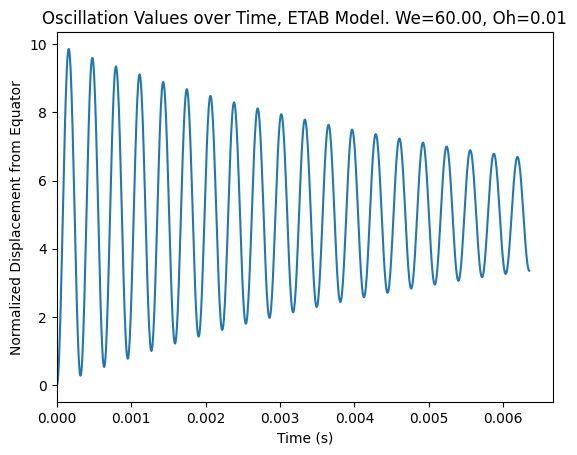

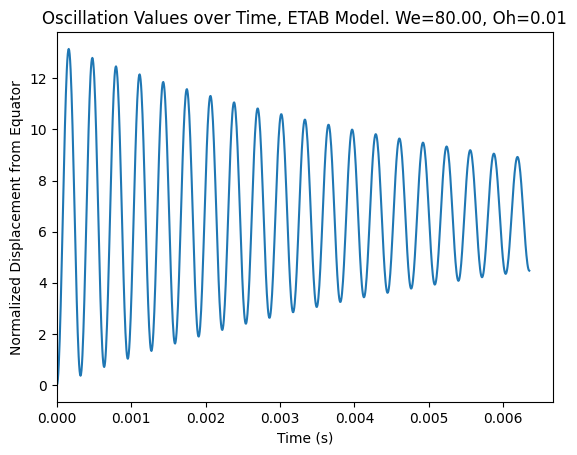

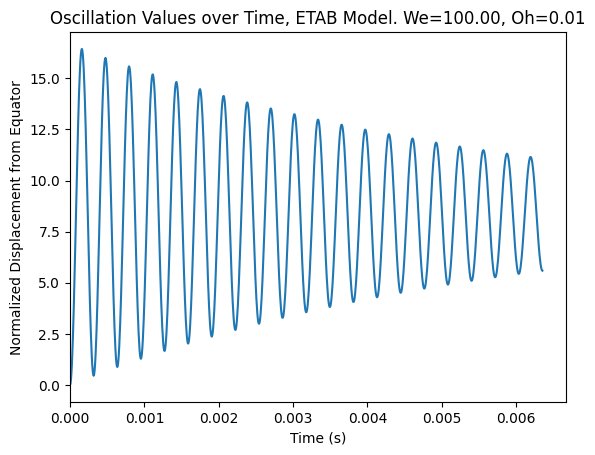

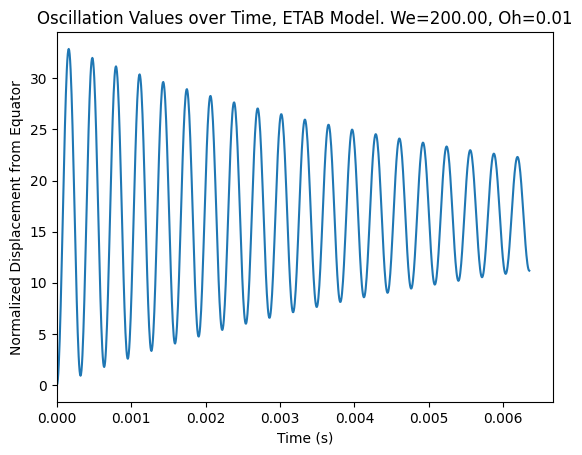

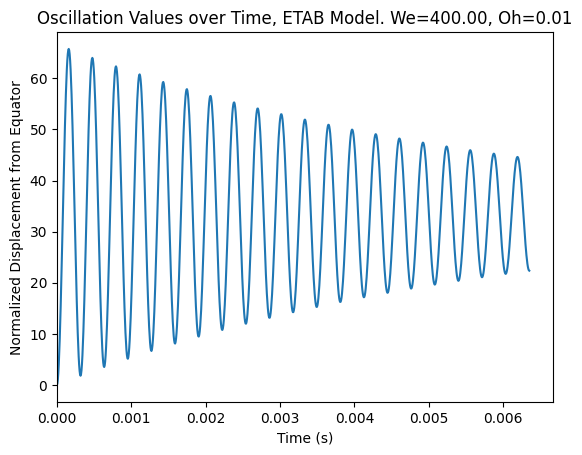

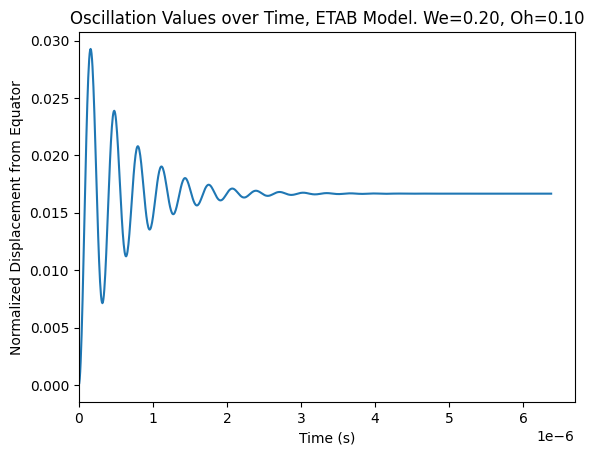

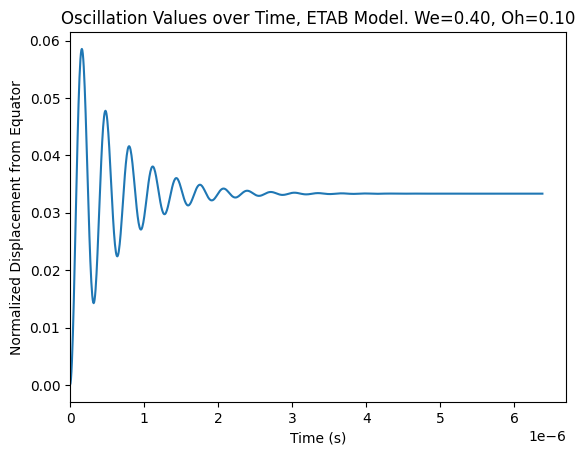

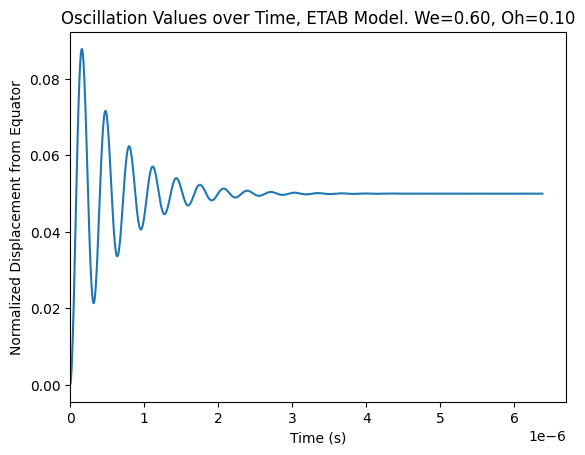

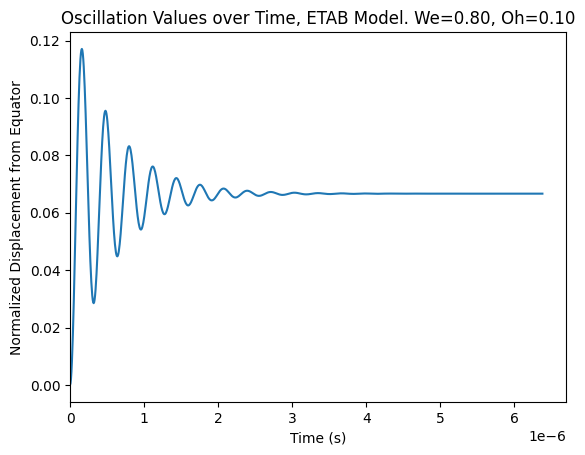

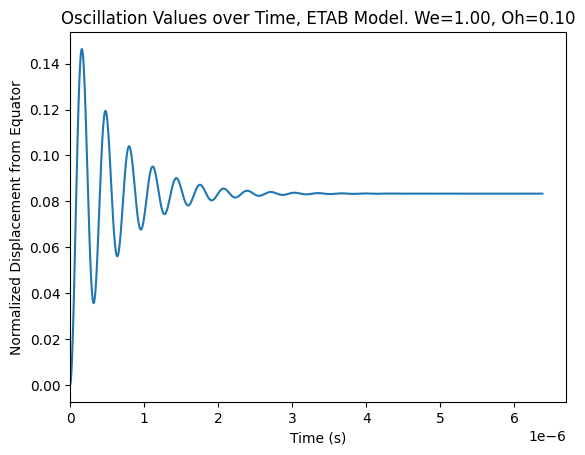

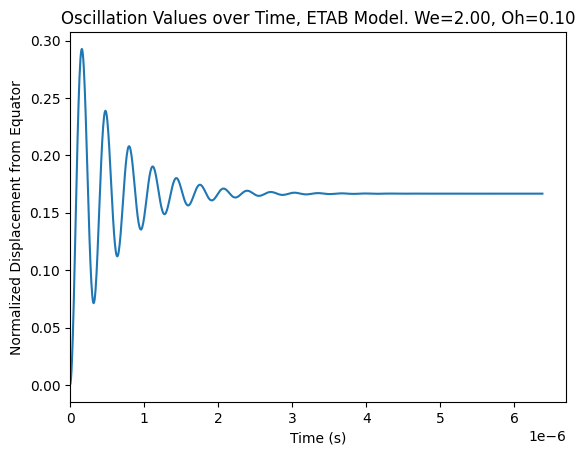

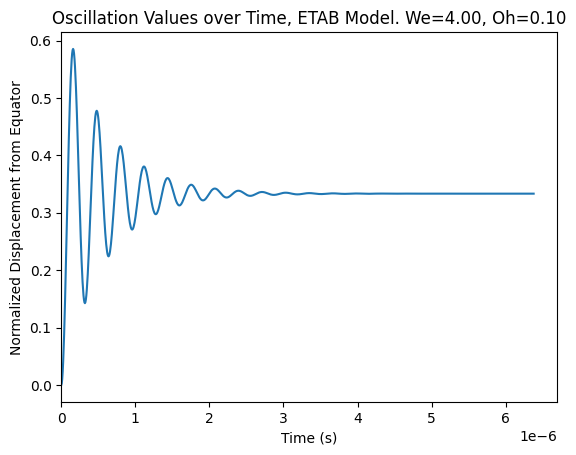

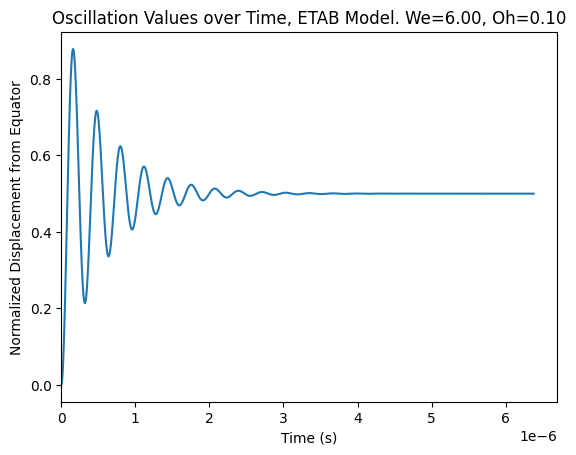

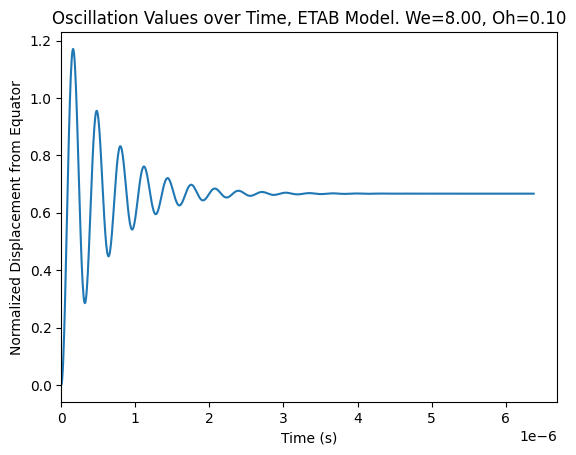

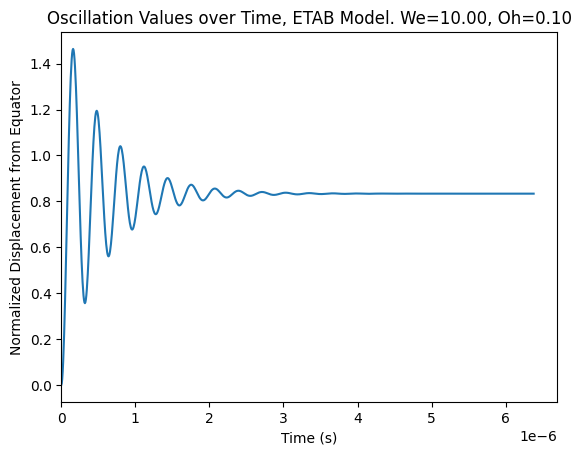

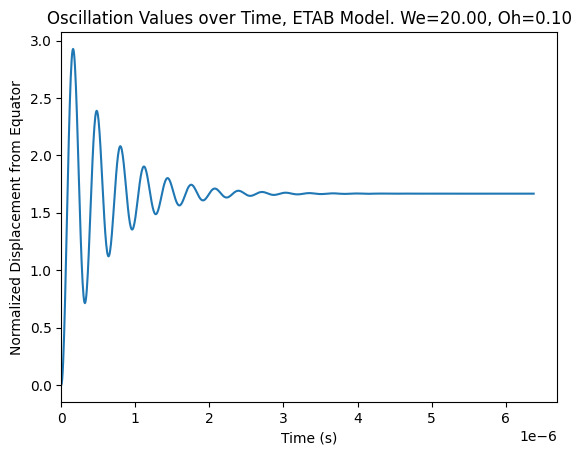

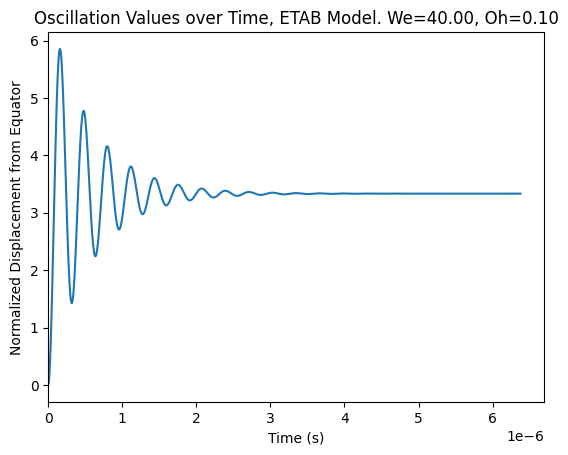

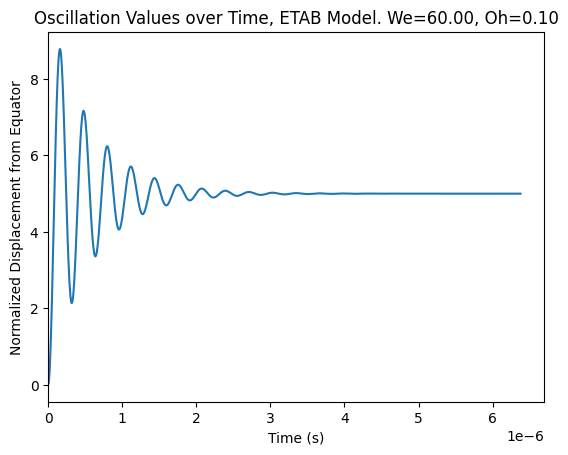

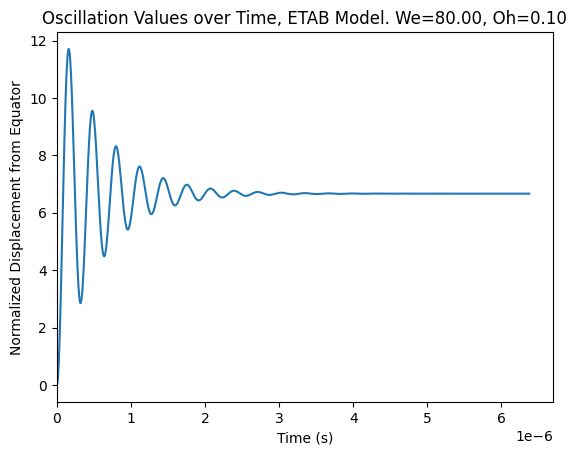

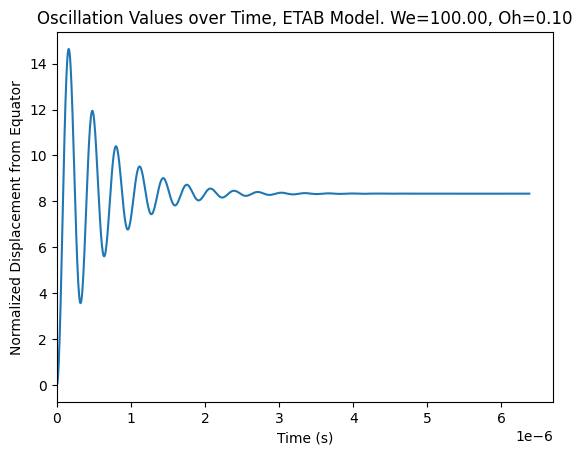

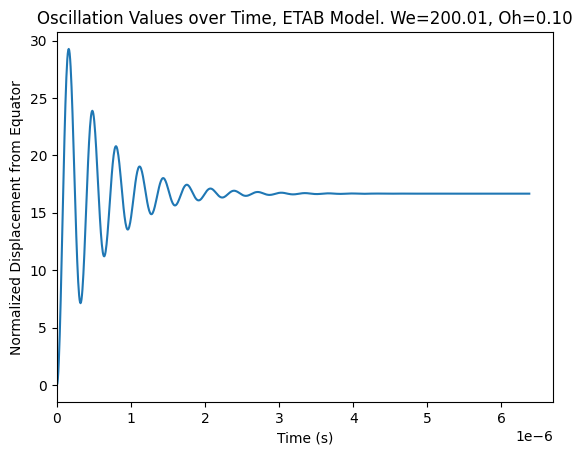

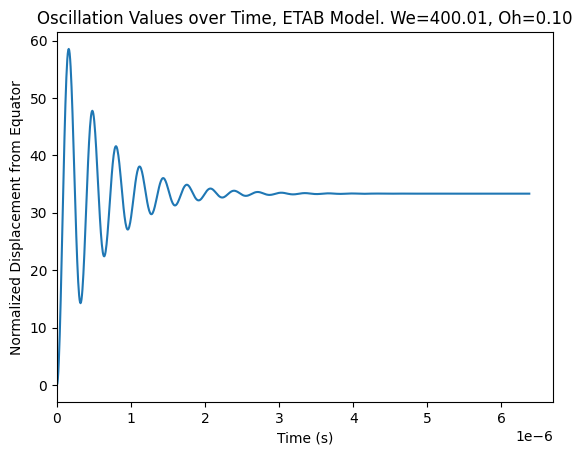

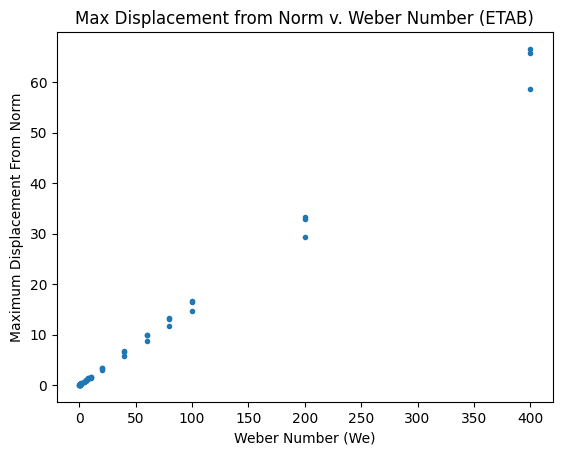

Regime Classifications (ETAB): ['5' '1' '1' '2' '2' 'o' 'o' 'o' 'b' 'b' 'b' 'b' 'b' 's' 's' 's' 'c' '5'
 '1' '1' '2' '2' 'o' 'o' 'o' 'b' 'b' 'b' 'b' 'b' 'b' 's' 's' 'c' '5' '1'
 '1' '2' '2' '>' 'o' 'o' 'b' 'b' 'b' 'b' 'b' 's' 's' 's' 'c']


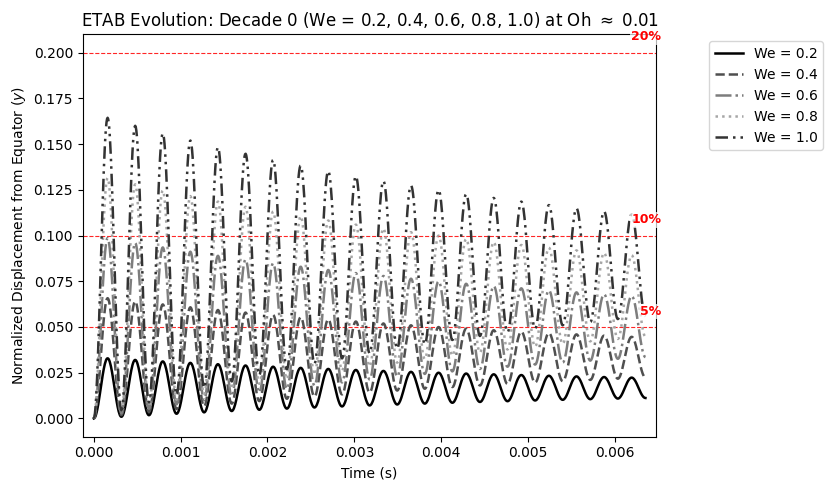

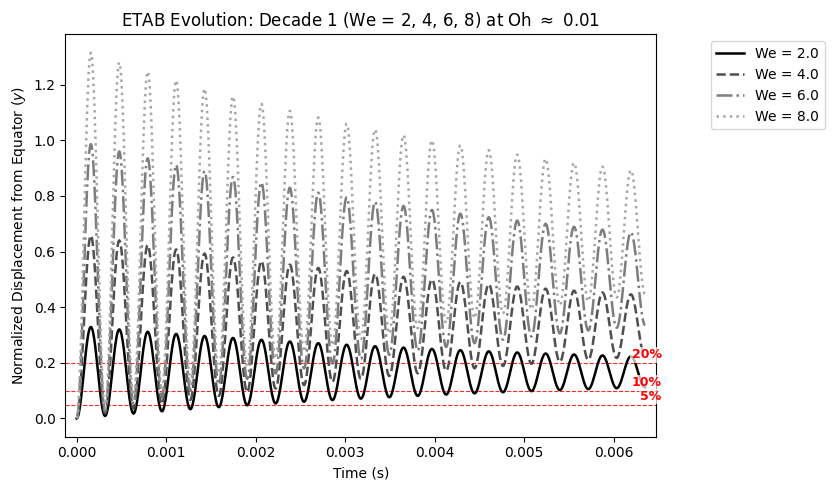

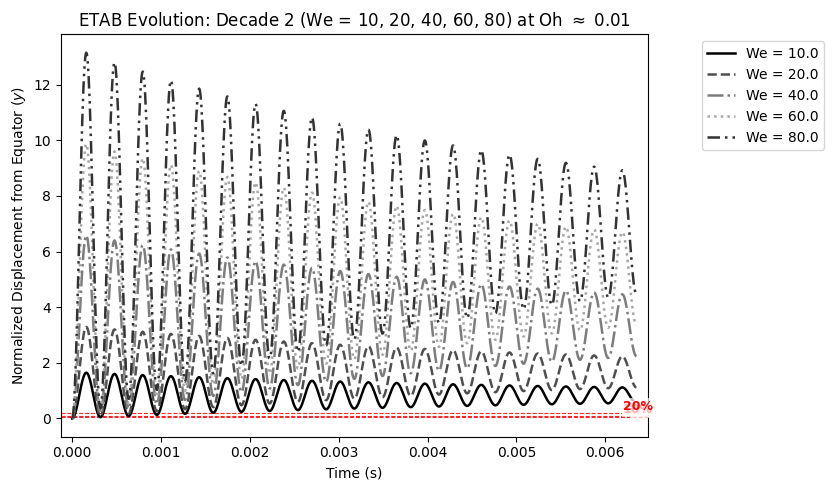

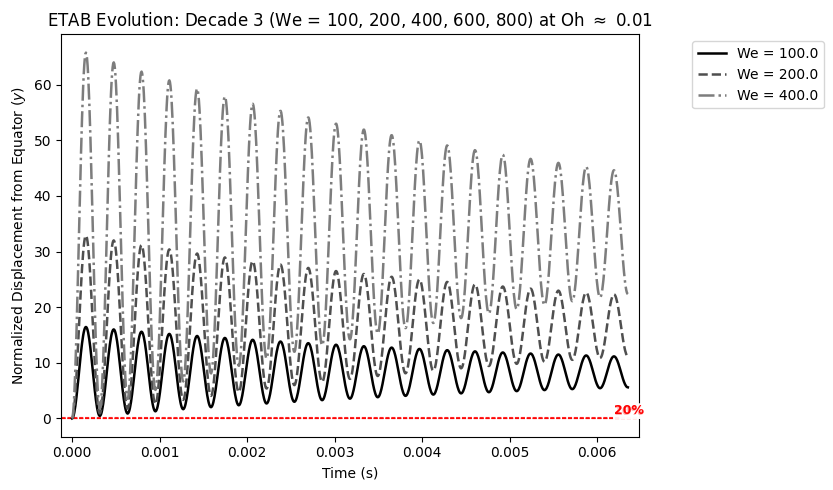

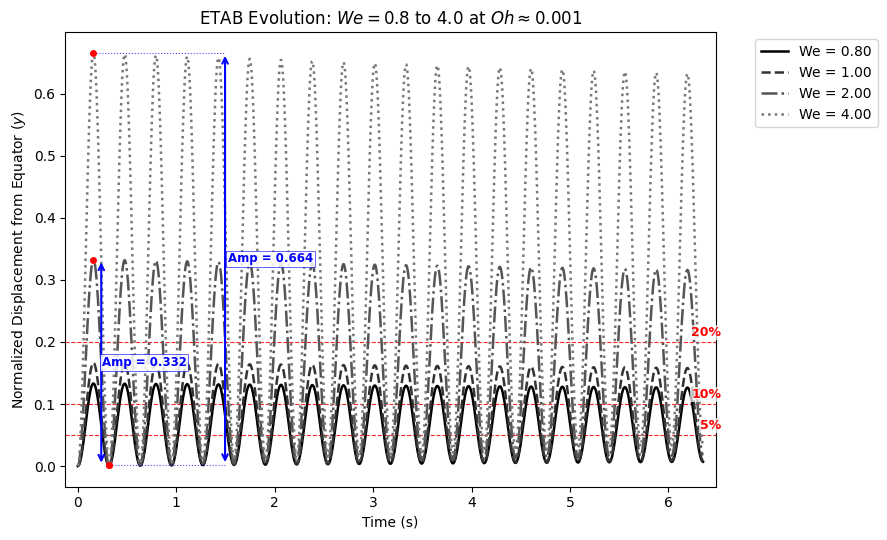

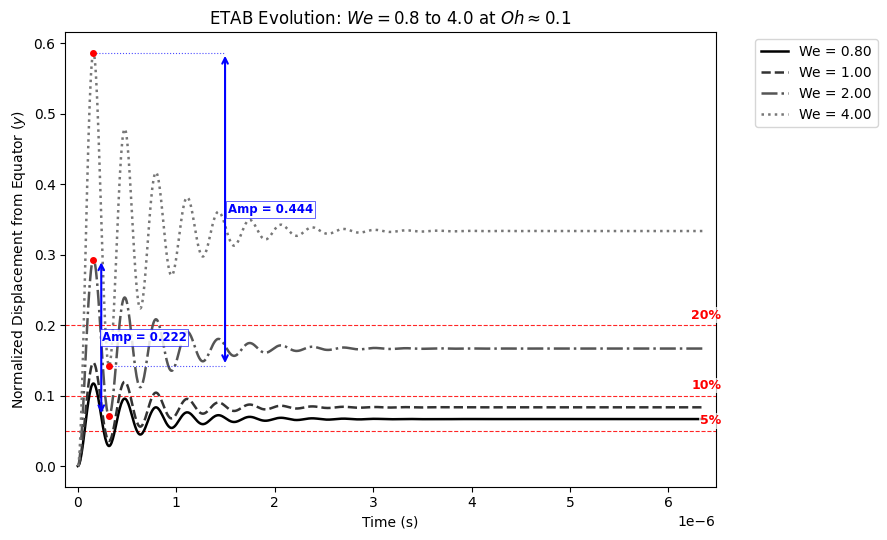

In [19]:
max_y_val_tanner = np.zeros(len(radius_values))  # array for max normalized displacement from sphere
We_tanner = np.zeros(len(radius_values))  # array for all the Weber numbers
regimes_Tan = np.empty(len(radius_values), dtype=str)
ratios = np.zeros(len(radius_values), dtype=float)
zeta = np.zeros(len(radius_values), dtype=float)

for k in range(len(radius_values)):

    #These values may be changed:
    rho_g = 1.18  #kg/m^3, density of gaseous ethylene
    rho_l = 997  #kg/m^3, density of liquid
    parent_r = radius_values[k]  #m, radius of droplet (~.2mm) **
    parent_vol = (4/3)*np.pi*(parent_r**3)
    sigma = 0.0708  #kg/s^2, surface tension
    u = velocity_values[k]  #m/s, velocity
    mu_l = 0.000894  #Pa*s, the dynamic viscocity of Jet A
    mu_g = 0.00185  #air viscosity, may change as a function of mach number (for Re)

    Oh = mu_l / np.sqrt( rho_l*parent_r*sigma )  #Ohnesorge number, from Faeth et al pg 636, between 10^-4 and 10^-2 for oscillatory behaviour
    We = rho_g*(u**2)*parent_r/sigma  #Weber number, eq 4
    We_tanner[k] = We

    Re = 2*rho_g*parent_r*u/mu_g

    volume = (4/3)*np.pi*parent_r**3  #a constant

    #Old implementation: assumes inital considitions are both 0. No time Marching.
    const1 = 5*mu_l/(rho_l*parent_r**2)
    const2 = 8*sigma/(rho_l*parent_r**3)
    const3 = 2*rho_g*u**2/(3*rho_l*parent_r**2)

    omega = np.sqrt( const2 - const1**2/4 )

    duration = 20*(2*np.pi/omega)  #seconds, the time we want to watch this particle
    len_t = 1000  #length of time vector

    dt = np.linspace(0,duration,len_t)  #s, time vector
    timestep = dt[1]-dt[0]  #timestep, in seconds

    y_vals = (const3/const2)*( 1 - np.exp(-const1*dt/2)*( np.cos(omega*dt) + (const1/(2*omega))*np.sin(omega*dt) ) )

    C_lambda = 5.5  #estimate from tanner paper
    d_0 = 0.15*1e-3  #0.15mm, from the table 2 tuning constant
    t_bu = C_lambda*d_0*np.sqrt(rho_l/rho_g)/u

    We_crit = 6
    We_bs = 80
    We_sc = 350

    for i in range(len_t):

        if (y_vals[i]>=1) and (const2-((const1**2)/4)>0) and (dt[i]>=t_bu):

            breakup_iteration = i

            Omega = np.sqrt( (8*sigma/(rho_l*(parent_r**3))) - (25*(mu_l**2)/(4*(rho_l**2)*(parent_r**4))) )

            K_br = 0
            k1 = 0.05  #tuned from CAB model in paper
            k2 = k1/np.sqrt(We_bs)  #calculated for continuity at We_bs
            k3 = k2/(We_sc**(1/4))  #calculated for continuity at We_sc

            #Define K_br from equation 3
            if We<=We_bs:
                K_br = k1*Omega  #Bag breakup
                regimes_Tan[k] = 'D'

            elif We<=We_sc:
                K_br = k2*Omega*np.sqrt(We)  #Stripping breakup
                regimes_Tan[k] = 'E'

            else:
                K_br = k3*Omega*(We**(3/4))  #Catastrophic breakup
                regimes_Tan[k] = 'F'

            min_radius = 1e-8  #10 nanometers as a safety floor
            product_r = parent_r*np.exp(-K_br*dt[i])  #Product drop radius, eq 4
            product_r = max(product_r,min_radius)

            product_vol = (4/3)*np.pi*(product_r**3)
            num_drops = int(np.round(parent_vol/product_vol))

            if num_drops>1e6:
                num_drops = 1e6  #cap at 1 mil drops per parent

            C_D = 0.44  #Schiller-Naumann correlation for CD of spherical bodies

            if Re<1:
                C_D = 24/Re

            elif Re<1000:
                C_D = 24/Re*(1 + 0.15*Re**0.687)

            r_32 = (parent_r**3)/(product_r**2)
            term = (5*C_D/4) + ( (18*(1-(parent_r/r_32)))/We )

            if term<0:
                term = -term

            A = np.sqrt(term)  #equation 8
            spray_angle = np.arctan(A)  #Spray angle measured from drop velocity vector
            vel_new = u*A  #Eq 5, new droplet normal velocities

            # den = parent_r - y_vals[i]*parent_r/2
            # den = max(den,1e-12)  #gaurd or else den --> 0 as y(i) --> 2 and b will --> infinity
            # b = np.sqrt(parent_r**3/den)  #radius of the zy plane circle

            # new_ypos = np.zeros(num_drops)
            # new_zpos = np.zeros(num_drops)
            # new_xvel = np.zeros(num_drops)
            # new_yvel = np.zeros(num_drops)
            # new_zvel = np.zeros(num_drops)

            # for j in range(num_drops):

            #     drop_angle = 2*np.pi*j/num_drops

            #     new_ypos[j] = b*np.sin(drop_angle)  #initial y pos
            #     new_zpos[j] = b*np.cos(drop_angle)  #inital z pos

            #     new_xvel[j] = vel_new*np.cos(spray_angle)  #x velocity, a constant
            #     new_yvel[j] = vel_new*np.sin(spray_angle)*np.sin(drop_angle)  #y velocity
            #     new_zvel[j] = vel_new*np.sin(spray_angle)*np.cos(drop_angle)  #z velocity

            # y_vals[i+1:] = 0
            break

    peak_indices, _ = find_peaks(y_vals)
    trough_indices, _ = find_peaks(-y_vals) # Detect local minima
    peak_values = y_vals[peak_indices]

    if len(peak_indices) > 0 and len(trough_indices) > 0:
            # The amplitude of the first full oscillation cycle
            oscillation_amplitude = y_vals[peak_indices[0]] - y_vals[trough_indices[0]]
    else:
        oscillation_amplitude = 0.0

    if np.max(y_vals)<=0.05:
        regimes_Tan[k] = '5'
    elif np.max(y_vals)<=0.1:
        regimes_Tan[k] = '10'
    elif np.max(y_vals)<=0.2:
        regimes_Tan[k] = '20'
    elif np.max(y_vals)+(We/12) <= 1 and oscillation_amplitude < 0.25:
        regimes_Tan[k] = '>20'
    elif np.max(y_vals)<=1:
        regimes_Tan[k] = 'osc'
    else:

        if We<=We_bs:
            regimes_Tan[k] = 'bag'

        elif We<=We_sc:
            regimes_Tan[k] = 'str'

        else:
            regimes_Tan[k] = 'cat'

    #Plotting the y values
    plt.figure()
    plt.plot(dt,y_vals)
    plt.title(f'Oscillation Values over Time, ETAB Model. We={We:.2f}, Oh={Oh:.2f}')
    plt.xlabel('Time (s)')
    plt.ylabel('Normalized Displacement from Equator')  #y = 2x/a

    max_y_val_tanner[k] = np.max(y_vals)

    plt.xlim(left=0)
    plt.show()

# ==============================================================================
# --- BASELINE DIAGNOSTIC PLOT (ETAB) ---
# ==============================================================================
plt.figure()
plt.plot(We_tanner, max_y_val_tanner, '.')
plt.title('Max Displacement from Norm v. Weber Number (ETAB)')
plt.xlabel('Weber Number (We)')
plt.ylabel('Maximum Displacement From Norm')
plt.margins(x=0.05, y=0.05)
plt.show()

print("Regime Classifications (ETAB):", regimes_Tan)


# ==============================================================================
# --- 2. MULTI-LINE DECADE GROUPED PLOTS BY TARGET OH (ETAB) ---
# ==============================================================================
decades = {
    "Decade 0 (We = 0.2, 0.4, 0.6, 0.8, 1.0)": [0.2, 0.4, 0.6, 0.8, 1.0],
    "Decade 1 (We = 2, 4, 6, 8)": [2, 4, 6, 8],
    "Decade 2 (We = 10, 20, 40, 60, 80)": [10, 20, 40, 60, 80],
    "Decade 3 (We = 100, 200, 400, 600, 800)": [100, 200, 400, 600, 800]
}

target_Oh = 0.01
oh_tolerance = 0.0005  # Tolerance window to group closely matched Oh numbers

linestyles = ['-', '--', '-.', ':', (0, (5, 2, 1, 2, 1, 2))]
grayscale_colors = ['#000000', '#4f4f4f', '#7d7d7d', '#a6a6a6', '#333333']

for decade_name, target_We_list in decades.items():
    fig, ax = plt.subplots(figsize=(8.5, 5))
    lines_plotted = 0
    
    for res in sim_results:
        if np.isclose(res['Oh'], target_Oh, atol=oh_tolerance):
            if any(np.isclose(res['We'], target_val, rtol=0.05) for target_val in target_We_list):
                
                style = linestyles[lines_plotted % len(linestyles)]
                color = grayscale_colors[lines_plotted % len(grayscale_colors)]
                
                ax.plot(
                    res['t'], 
                    res['y'], 
                    linestyle=style, 
                    color=color, 
                    linewidth=1.8,
                    label=f'We = {res["We"]:.1f}'
                )
                lines_plotted += 1
                
    if lines_plotted > 0:
        y_thresholds = [0.05, 0.1, 0.2]
        labels = ["5%", "10%", "20%"]
        
        x_min, x_max = ax.get_xlim()
        
        for y_val, label_text in zip(y_thresholds, labels):
            ax.axhline(y=y_val, color='red', linestyle='--', linewidth=0.8, alpha=0.85, zorder=1)
            ax.text(
                x_max * 0.98, y_val + 0.005, label_text, 
                color='red', fontsize=9, fontweight='bold', 
                ha='right', va='bottom', zorder=5,
                bbox=dict(boxstyle='square,pad=0.1', facecolor='white', edgecolor='none', alpha=0.7)
            )

        ax.set_title(f'ETAB Evolution: {decade_name} at Oh $\\approx$ {target_Oh}')
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Normalized Displacement from Equator ($y$)')
        ax.legend(bbox_to_anchor=(1.08, 1), loc='upper left')
        ax.margins(x=0.02, y=0.05)
        plt.tight_layout()
        plt.show()
    else:
        plt.close(fig)


# ==============================================================================
# --- 3. STANDALONE PLOT: We = 0.8 TO 4.0 AT Oh ≈ 0.001 (ETAB) ---
# ==============================================================================
target_Oh = 0.001        # Target Ohnesorge cluster
oh_tolerance = 0.0005    # Window around target Oh

we_min, we_max = 0.8, 4.0
target_runs = [
    res for res in sim_results 
    if np.isclose(res['Oh'], target_Oh, atol=oh_tolerance) 
    and (we_min - 0.05 <= res['We'] <= we_max + 0.05)
]

target_runs.sort(key=lambda x: x['We'])

if target_runs:
    fig, ax = plt.subplots(figsize=(9, 5.5))
    
    linestyles = ['-', '--', '-.', ':', (0, (5, 2, 1, 2, 1, 2))]
    grayscale_colors = ['#000000', '#333333', '#555555', '#777777', '#999999', '#bbbbbb']
    
    target_amp_we_list = [2.0, 4.0]

    for idx, res in enumerate(target_runs):
        style = linestyles[idx % len(linestyles)]
        color = grayscale_colors[idx % len(grayscale_colors)]
        
        ax.plot(
            res['t'], 
            res['y'], 
            linestyle=style, 
            color=color, 
            linewidth=1.8,
            label=f'We = {res["We"]:.2f}'
        )
        
        # --- HIGHLIGHT OSCILLATION AMPLITUDES FOR WE = 2 AND WE = 4 ---
        if any(np.isclose(res['We'], target_we, rtol=0.1) for target_we in target_amp_we_list):
            y_vals_curve = res['y']
            t_vals_curve = res['t']
            
            peaks, _ = find_peaks(y_vals_curve)
            troughs, _ = find_peaks(-y_vals_curve)
            
            if len(peaks) > 0 and len(troughs) > 0:
                # Always measure Cycle 1 (1st Peak to 1st Trough)
                t_p1, y_p1 = t_vals_curve[peaks[0]], y_vals_curve[peaks[0]]
                t_t1, y_t1 = t_vals_curve[troughs[0]], y_vals_curve[troughs[0]]
                
                # Plot red dots at exact physical Peak 1 and Trough 1
                ax.plot(t_p1, y_p1, 'ro', markersize=4, zorder=6)
                ax.plot(t_t1, y_t1, 'ro', markersize=4, zorder=6)
                
                t_arrow = (t_p1 + t_t1) / 2
                
                # Push We = 4.0 arrow significantly right (18% of plot width) to sit clear past the second wave
                if res['We'] > 3.0:
                    dt_shift = (ax.get_xlim()[1] - ax.get_xlim()[0]) * 0.18
                    arrow_x = t_arrow + dt_shift
                    
                    # Extended horizontal dotted guidelines back to Peak 1 and Trough 1
                    ax.plot([t_p1, arrow_x], [y_p1, y_p1], 'b:', lw=0.8, alpha=0.7, zorder=5)
                    ax.plot([t_t1, arrow_x], [y_t1, y_t1], 'b:', lw=0.8, alpha=0.7, zorder=5)
                else:
                    arrow_x = t_arrow

                # Draw physical double-headed vertical arrow measuring Cycle 1 height
                ax.annotate(
                    '', xy=(arrow_x, y_t1), xytext=(arrow_x, y_p1),
                    arrowprops=dict(arrowstyle='<->', color='blue', lw=1.5),
                    zorder=6
                )
                
                amp = y_p1 - y_t1
                ax.text(
                    arrow_x * 1.02, (y_p1 + y_t1) / 2, 
                    f'Amp = {amp:.3f}', 
                    color='blue', fontsize=8.5, fontweight='bold', va='center',
                    bbox=dict(boxstyle='square,pad=0.15', facecolor='white', edgecolor='blue', lw=0.5, alpha=0.85),
                    zorder=6
                )

    # --- RED HORIZONTAL THRESHOLD LINES & INLINE LABELS ---
    y_thresholds = [0.05, 0.1, 0.2]
    labels = ["5%", "10%", "20%"]
    x_min, x_max = ax.get_xlim()
    
    for y_val, label_text in zip(y_thresholds, labels):
        ax.axhline(y=y_val, color='red', linestyle='--', linewidth=0.8, alpha=0.85, zorder=1)
        ax.text(
            x_max * 0.98, y_val + 0.005, label_text, 
            color='red', fontsize=9, fontweight='bold', ha='right', va='bottom', zorder=5,
            bbox=dict(boxstyle='square,pad=0.1', facecolor='white', edgecolor='none', alpha=0.7)
        )

    ax.set_title(f'ETAB Evolution: $We = 0.8$ to $4.0$ at $Oh \\approx {target_Oh}$')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Normalized Displacement from Equator ($y$)')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.margins(x=0.02, y=0.05)
    plt.tight_layout()
    plt.show()


# ==============================================================================
# --- 4. STANDALONE PLOT: We = 0.8 TO 4.0 AT Oh ≈ 0.1 (ETAB) ---
# ==============================================================================
target_Oh = 0.1          # Target Ohnesorge cluster
oh_tolerance = 0.05      # Window around target Oh

we_min, we_max = 0.8, 4.0
target_runs = [
    res for res in sim_results 
    if np.isclose(res['Oh'], target_Oh, atol=oh_tolerance) 
    and (we_min - 0.05 <= res['We'] <= we_max + 0.05)
]

target_runs.sort(key=lambda x: x['We'])

if target_runs:
    fig, ax = plt.subplots(figsize=(9, 5.5))
    
    linestyles = ['-', '--', '-.', ':', (0, (5, 2, 1, 2, 1, 2))]
    grayscale_colors = ['#000000', '#333333', '#555555', '#777777', '#999999', '#bbbbbb']
    
    target_amp_we_list = [2.0, 4.0]

    for idx, res in enumerate(target_runs):
        style = linestyles[idx % len(linestyles)]
        color = grayscale_colors[idx % len(grayscale_colors)]
        
        ax.plot(
            res['t'], 
            res['y'], 
            linestyle=style, 
            color=color, 
            linewidth=1.8,
            label=f'We = {res["We"]:.2f}'
        )
        
        # --- HIGHLIGHT OSCILLATION AMPLITUDES FOR WE = 2 AND WE = 4 ---
        if any(np.isclose(res['We'], target_we, rtol=0.1) for target_we in target_amp_we_list):
            y_vals_curve = res['y']
            t_vals_curve = res['t']
            
            peaks, _ = find_peaks(y_vals_curve)
            troughs, _ = find_peaks(-y_vals_curve)
            
            if len(peaks) > 0 and len(troughs) > 0:
                # Always measure Cycle 1 (1st Peak to 1st Trough)
                t_p1, y_p1 = t_vals_curve[peaks[0]], y_vals_curve[peaks[0]]
                t_t1, y_t1 = t_vals_curve[troughs[0]], y_vals_curve[troughs[0]]
                
                # Plot red dots at exact physical Peak 1 and Trough 1
                ax.plot(t_p1, y_p1, 'ro', markersize=4, zorder=6)
                ax.plot(t_t1, y_t1, 'ro', markersize=4, zorder=6)
                
                t_arrow = (t_p1 + t_t1) / 2
                
                # Push We = 4.0 arrow significantly right (18% of plot width) to sit clear past the second wave
                if res['We'] > 3.0:
                    dt_shift = (ax.get_xlim()[1] - ax.get_xlim()[0]) * 0.18
                    arrow_x = t_arrow + dt_shift
                    
                    # Extended horizontal dotted guidelines back to Peak 1 and Trough 1
                    ax.plot([t_p1, arrow_x], [y_p1, y_p1], 'b:', lw=0.8, alpha=0.7, zorder=5)
                    ax.plot([t_t1, arrow_x], [y_t1, y_t1], 'b:', lw=0.8, alpha=0.7, zorder=5)
                else:
                    arrow_x = t_arrow

                # Draw physical double-headed vertical arrow measuring Cycle 1 height
                ax.annotate(
                    '', xy=(arrow_x, y_t1), xytext=(arrow_x, y_p1),
                    arrowprops=dict(arrowstyle='<->', color='blue', lw=1.5),
                    zorder=6
                )
                
                amp = y_p1 - y_t1
                ax.text(
                    arrow_x * 1.02, (y_p1 + y_t1) / 2, 
                    f'Amp = {amp:.3f}', 
                    color='blue', fontsize=8.5, fontweight='bold', va='center',
                    bbox=dict(boxstyle='square,pad=0.15', facecolor='white', edgecolor='blue', lw=0.5, alpha=0.85),
                    zorder=6
                )

    # --- RED HORIZONTAL THRESHOLD LINES & INLINE LABELS ---
    y_thresholds = [0.05, 0.1, 0.2]
    labels = ["5%", "10%", "20%"]
    x_min, x_max = ax.get_xlim()
    
    for y_val, label_text in zip(y_thresholds, labels):
        ax.axhline(y=y_val, color='red', linestyle='--', linewidth=0.8, alpha=0.85, zorder=1)
        ax.text(
            x_max * 0.98, y_val + 0.005, label_text, 
            color='red', fontsize=9, fontweight='bold', ha='right', va='bottom', zorder=5,
            bbox=dict(boxstyle='square,pad=0.1', facecolor='white', edgecolor='none', alpha=0.7)
        )

    ax.set_title(f'ETAB Evolution: $We = 0.8$ to $4.0$ at $Oh \\approx {target_Oh}$')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Normalized Displacement from Equator ($y$)')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.margins(x=0.02, y=0.05)
    plt.tight_layout()
    plt.show()

In [20]:
# ==============================================================================
# --- COMPARISON PLOT: TAB vs. ETAB AT We = 60.0 & Oh = 0.001 ---
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np

target_We = 60.0
target_Oh = 0.001
we_tol = 0.1
oh_tol = 0.0005

# 1. ETAB results from Tanner script
runs_etab = globals().get('sim_results', [])

# 2. AUTOMATIC SCANNER: Find any other list in workspace containing sim data
runs_tab = []
for var_name, var_val in list(globals().items()):
    if var_name.startswith('_') or var_name == 'sim_results':
        continue
    if isinstance(var_val, list) and len(var_val) > 0:
        # Check if first element is a dict with 'We' and 'Oh'
        if isinstance(var_val[0], dict) and 'We' in var_val[0] and 'Oh' in var_val[0]:
            print(f"Found TAB candidates in variable: '{var_name}' ({len(var_val)} runs)")
            runs_tab = var_val
            break

# Extract matching runs
tab_run = next(
    (res for res in runs_tab 
     if np.isclose(res['We'], target_We, atol=we_tol) 
     and np.isclose(res['Oh'], target_Oh, atol=oh_tol)), 
    None
)

etab_run = next(
    (res for res in runs_etab 
     if np.isclose(res['We'], target_We, atol=we_tol) 
     and np.isclose(res['Oh'], target_Oh, atol=oh_tol)), 
    None
)

if tab_run is not None and etab_run is not None:
    fig, ax = plt.subplots(figsize=(9.5, 6))

    # --- PLOT TAB & ETAB WAVE CURVES ---
    ax.plot(tab_run['t'], tab_run['y'], 'k-', linewidth=1.8, label='TAB Model')
    ax.plot(etab_run['t'], etab_run['y'], 'k--', linewidth=1.8, label='ETAB Model')

    # --- BREAKUP THRESHOLDS ---
    y_thresh_etab = 1.0
    y_thresh_tab = 1.0 - (target_We / 12.0)

    # Distinct black dotted line patterns
    ax.axhline(
        y=y_thresh_etab, color='black', linestyle=(0, (1, 1.5)), 
        linewidth=1.2, alpha=0.85, zorder=3, label='ETAB Thresh: $y = 1$'
    )
    ax.axhline(
        y=y_thresh_tab, color='black', linestyle=(0, (3, 1.2, 1, 1.2)), 
        linewidth=1.2, alpha=0.85, zorder=3, label=f'TAB Thresh: $y = 1 - We/12$ ({y_thresh_tab:.2f})'
    )

    # Inline text labels for threshold lines
    x_max = ax.get_xlim()[1]
    ax.text(
        x_max * 0.98, y_thresh_etab + 0.05, 'ETAB $y = 1$', 
        color='black', fontsize=8.5, fontweight='bold', ha='right', va='bottom',
        bbox=dict(boxstyle='square,pad=0.1', facecolor='white', edgecolor='none', alpha=0.7)
    )
    ax.text(
        x_max * 0.98, y_thresh_tab + 0.05, 'TAB $y = 1 - (We/12)$', 
        color='black', fontsize=8.5, fontweight='bold', ha='right', va='bottom',
        bbox=dict(boxstyle='square,pad=0.1', facecolor='white', edgecolor='none', alpha=0.7)
    )

    # --- TAB BREAKUP TIME (t_bu) DOUBLE ARROW ---
    if 't_bu' in tab_run:
        t_bu = tab_run['t_bu']
    else:
        rho_l = tab_run.get('rho_l', 800.0)
        rho_g = tab_run.get('rho_g', 1.2)
        r0 = tab_run.get('r0', 1e-4)
        u_rel = tab_run.get('u_rel', 50.0)
        t_bu = 8.0 * np.sqrt((rho_l * r0) / (rho_g * (u_rel**2)))

    # Position arrow near top of plot area
    y_max_plot = ax.get_ylim()[1]
    y_arrow = y_max_plot * 0.88

    # Anchor dots at t=0 and t=t_bu
    ax.plot(0, y_arrow, 'ro', markersize=4, zorder=6)
    ax.plot(t_bu, y_arrow, 'ro', markersize=4, zorder=6)

    # Double-headed arrow
    ax.annotate(
        '', xy=(0, y_arrow), xytext=(t_bu, y_arrow),
        arrowprops=dict(arrowstyle='<->', color='blue', lw=1.5),
        zorder=6
    )

    ax.text(
        t_bu / 2.0, y_arrow + (y_max_plot * 0.03), 
        f'TAB breakup time ($t_{{bu}} = {t_bu:.3e}\\ s$)', 
        color='blue', fontsize=8.5, fontweight='bold', ha='center', va='bottom',
        bbox=dict(boxstyle='square,pad=0.15', facecolor='white', edgecolor='blue', lw=0.5, alpha=0.85),
        zorder=6
    )

    # --- FORMATTING ---
    ax.set_title(f'TAB vs. ETAB Evolution ($We = {target_We:.1f}, Oh = {target_Oh}$)')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Normalized Displacement ($y$)')
    ax.legend(loc='lower right')
    ax.margins(x=0.02, y=0.12)
    plt.tight_layout()
    plt.show()

else:
    print(f"Still looking for TAB runs. If TAB results were saved in a separate script or overwritten, re-run your TAB loop first!")

Found TAB candidates in variable: 'target_runs' (4 runs)
Still looking for TAB runs. If TAB results were saved in a separate script or overwritten, re-run your TAB loop first!
